In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
from scipy import stats
from scipy.spatial import cKDTree
from sklearn.linear_model import LinearRegression


In [3]:
data_dir = os.path.expanduser("~/DataFiles")
racmo_smb_file = data_dir + "/smbgl_monthlyS_ANT11_RACMO2.4p1_ERA5_197901_202512.nc"
racmo_t2m_file = data_dir + "/tas_monthlyA_ANT11_RACMO2.4p1_ERA5_197901_202512.nc"
racmo_mask_file = data_dir + "/TotIS_RACMO_ANT27_IMBIE2.nc"
ant11_mask_file = data_dir + "/ANT11_masks.nc"
ant27_ref_file  = data_dir + "/smb_monthlyS_ANT27_ERA5-3H_RACMO2.3p2_197901_202212.nc"
accum_data_file   = data_dir + "/AccumCoresData.csv"
water_data_file   = data_dir + "/WaterCoresData.csv"
accum_coords_file = data_dir + "/AccumCoresCoords.csv"
water_coords_file = data_dir + "/WaterCoresCoords.csv"


In [4]:
smb_ds = xr.open_dataset(racmo_smb_file)
smb_ann = (smb_ds["smbgl"].squeeze("height").groupby("time.year").sum("time").sel(year=slice(1979, 2025)))
t2m_ds = xr.open_dataset(racmo_t2m_file)
t2m_ann = (t2m_ds["tas"].squeeze("height").groupby("time.year").mean("time").sel(year=slice(1979, 2025)))
lat_racmo = smb_ann["lat"].values; lon_racmo = smb_ann["lon"].values
NY, NX = lat_racmo.shape
years_obs = smb_ann["year"].values
print("ANT11 grid:", (NY, NX), " years", int(years_obs.min()), "-", int(years_obs.max()))


ANT11 grid: (591, 726)  years 1979 - 2025


In [5]:
mask_ds = xr.open_dataset(ant11_mask_file)
cell_area_m2 = mask_ds["Area"].values * 1e6
ice_sheet    = mask_ds["Icesheet_Only"].values == 1

def to_xyz(lat, lon):
    la, lo = np.deg2rad(lat), np.deg2rad(lon)
    return np.stack([np.cos(la)*np.cos(lo), np.cos(la)*np.sin(lo), np.sin(la)], -1)

ref27 = xr.open_dataset(ant27_ref_file)["smb"].squeeze("height")
lat27, lon27 = ref27["lat"].values, ref27["lon"].values
gi = xr.open_dataset(racmo_mask_file)["GroundedIce"].values
gi = np.where(np.isfinite(gi), gi, 0).astype(int); _gm = gi > 0
_, _idx = cKDTree(to_xyz(lat27[_gm].ravel(), lon27[_gm].ravel())).query(to_xyz(lat_racmo.ravel(), lon_racmo.ravel()))
basin_mask = np.where(ice_sheet.ravel(), gi[_gm].ravel()[_idx], 0).reshape(NY, NX)

basin_flat  = basin_mask.reshape(-1); valid_cells = basin_flat > 0
basin_ids   = basin_flat[valid_cells].astype(int); basin_ids_unique = np.unique(basin_ids)
ais_mask  = basin_mask > 0
wais_mask = np.isin(basin_mask, [3, 7, 8, 9, 10])
eais_mask = np.isin(basin_mask, [1, 2, 11, 12, 13, 14, 15, 16, 17, 18])
ap_mask   = np.isin(basin_mask, [4, 5, 6])
masks = {"AIS": ais_mask, "WAIS": wais_mask, "EAIS": eais_mask, "AP": ap_mask}
region_names = ["AIS", "WAIS", "EAIS", "AP"]
print("grounded cells:", int(valid_cells.sum()))


grounded cells: 113482


In [6]:
def basin_sums_Gt(field3d, years):
    mass = field3d * cell_area_m2
    df = pd.DataFrame(index=list(np.asarray(years)), columns=basin_ids_unique, dtype=float)
    for t, yr in enumerate(np.asarray(years)):
        flat = mass[t].reshape(-1)[valid_cells]
        s = pd.DataFrame({"basin": basin_ids, "m": flat}).groupby("basin")["m"].sum() / 1e12
        df.loc[yr, s.index] = s.values
    return df


In [7]:
smb_basin_obs = basin_sums_Gt(smb_ann.values, years_obs)
ais_rac  = smb_basin_obs.sum(axis=1).astype(float)
wais_rac = smb_basin_obs[[3,7,8,9,10]].sum(axis=1).astype(float)
eais_rac = smb_basin_obs[[1,2,11,12,13,14,15,16,17,18]].sum(axis=1).astype(float)
ap_rac   = smb_basin_obs[[4,5,6]].sum(axis=1).astype(float)
raw_series = {"AIS": ais_rac, "WAIS": wais_rac, "EAIS": eais_rac, "AP": ap_rac}


In [8]:
accum_data_raw = pd.read_csv(accum_data_file, header=None)
water_data_raw = pd.read_csv(water_data_file, header=None)
def extract_cores(raw_df, yr_min, yr_max, transpose=True):
    years_col = raw_df.iloc[2:, 0].astype(int)
    m = (years_col >= yr_min) & (years_col <= yr_max)
    arr = raw_df.iloc[2:, 1:][m].to_numpy()[::-1].astype(float)
    return arr.T if transpose else arr

N_CAL = 42; CAL_YEARS = slice(1979, 2020); recon_years = np.arange(1801, 2001)
accum_cores_cal  = extract_cores(accum_data_raw, 1979, 2020)
water_cores_cal  = extract_cores(water_data_raw, 1979, 2020)
accum_cores_full = extract_cores(accum_data_raw, 1801, 2000, transpose=False)
water_cores_full = extract_cores(water_data_raw, 1801, 2000, transpose=False)

accum_coords = pd.read_csv(accum_coords_file, header=None)
water_coords = pd.read_csv(water_coords_file, header=None)
core_lats  = accum_coords.iloc[:, 2].values; core_lons  = (accum_coords.iloc[:, 3].values + 360) % 360
water_lats = water_coords.iloc[:, 2].values; water_lons = (water_coords.iloc[:, 3].values + 360) % 360
print("accum cores:", accum_cores_full.shape[1], " water cores:", water_cores_full.shape[1])


accum cores: 84  water cores: 80


In [9]:
def nearest_ij(lat2d, lon2d, tlat, tlon):
    lon360 = (lon2d + 360) % 360
    d2 = (lat2d - tlat)**2 + (lon360 - (tlon + 360) % 360)**2
    return np.unravel_index(np.argmin(d2), d2.shape)

smb_cal = smb_ann.sel(year=CAL_YEARS).values; t2m_cal = t2m_ann.sel(year=CAL_YEARS).values
accum_pts = np.zeros((84, N_CAL)); R_accum = np.zeros(84)
for i in range(84):
    j, k = nearest_ij(lat_racmo, lon_racmo, core_lats[i], core_lons[i])
    smb_pt = smb_cal[:, j, k]; obs = accum_cores_cal[i, :]; accum_pts[i, :] = smb_pt
    v = np.isfinite(obs) & np.isfinite(smb_pt)
    reg = LinearRegression().fit(smb_pt[v].reshape(-1,1), obs[v].reshape(-1,1))
    R_accum[i] = np.var(obs[v].reshape(-1,1) - reg.predict(smb_pt[v].reshape(-1,1)), ddof=1)
_valid = np.isfinite(accum_cores_cal) & np.isfinite(accum_pts)
_off = (np.nanmean(np.where(_valid, accum_cores_cal, np.nan), axis=1)
        - np.nanmean(np.where(_valid, accum_pts, np.nan), axis=1))
y_e_accum = accum_pts + _off[:, None]

y_e_water = np.zeros((80, N_CAL)); R_water = np.zeros(80)
for i in range(80):
    j, k = nearest_ij(lat_racmo, lon_racmo, water_lats[i], water_lons[i])
    t_pt = t2m_cal[:, j, k]; obs = water_cores_cal[i, :]
    v = np.isfinite(obs) & np.isfinite(t_pt)
    reg = LinearRegression().fit(t_pt[v].reshape(-1,1), obs[v].reshape(-1,1))
    y_e_water[i, :] = t_pt * reg.coef_[0][0] + reg.intercept_[0]
    R_water[i] = np.var(obs[v].reshape(-1,1) - reg.predict(t_pt[v].reshape(-1,1)), ddof=1)

y_e_smb    = np.vstack([y_e_accum, y_e_water])
R_smb_diag = np.concatenate([R_accum, R_water])
proxy_smb  = np.hstack([accum_cores_full, water_cores_full])
print("PSMs ready. y_e_smb", y_e_smb.shape)


PSMs ready. y_e_smb (164, 42)


In [10]:
def run_ensrf_spatial_unc(prior_cells, y_e, R_diag_vec, proxy_data_full, n_proxy, integ):
    Ns = prior_cells.shape[1]
    post_mean = np.zeros((200, Ns), np.float32); post_std = np.zeros((200, Ns), np.float32)
    reg_ens = np.zeros((200, N_CAL, integ.shape[0]))
    for i in range(200):
        X_mean = prior_cells.mean(axis=0); X_dev = prior_cells - X_mean
        for j in range(n_proxy):
            if np.isnan(proxy_data_full[i, j]): continue
            y_mean = y_e[j, :].mean(); y_var = np.var(y_e[j, :], ddof=1)
            if not np.isfinite(y_mean) or y_var == 0: continue
            y_dev = y_e[j, :] - y_mean
            K = ((X_dev.T @ y_dev) / (N_CAL - 1)) / (y_var + R_diag_vec[j])
            X_mean = X_mean + K * (proxy_data_full[i, j] - y_mean)
            alpha = 1.0 / (1.0 + np.sqrt(R_diag_vec[j] / (y_var + R_diag_vec[j])))
            X_dev = X_dev - alpha * np.outer(y_dev, K)
        post_mean[i] = X_mean; post_std[i] = X_dev.std(axis=0, ddof=1)
        reg_ens[i] = (integ @ (X_mean[None, :] + X_dev).T).T
    return post_mean, post_std, reg_ens


In [11]:
# --- SMB reconstruction (UNCORRECTED): regional + basin ensembles + posterior-mean cube ---
_va = cell_area_m2.reshape(-1)[valid_cells]
_regions = {"AIS": basin_ids > 0, "WAIS": np.isin(basin_ids, [3,7,8,9,10]),
            "EAIS": np.isin(basin_ids, [1,2,11,12,13,14,15,16,17,18]), "AP": np.isin(basin_ids, [4,5,6])}
A_smb   = np.vstack([np.where(_regions[r], _va, 0) / 1e12 for r in region_names])
A_basin = np.vstack([np.where(basin_ids == b, _va, 0) / 1e12 for b in basin_ids_unique])
A_all   = np.vstack([A_smb, A_basin])

smb_cells = smb_ann.sel(year=CAL_YEARS).values.reshape(N_CAL, -1)[:, valid_cells].astype(np.float32)
print("Running SMB EnSRF (%d grounded cells) ..." % smb_cells.shape[1])
smb_post_v, smb_std_v, reg_ens_all = run_ensrf_spatial_unc(smb_cells, y_e_smb, R_smb_diag, proxy_smb, 164, A_all)
smb_reg_ens   = reg_ens_all[:, :, :4]       # (200, N_CAL, 4)  regional ensemble  (UNCORRECTED — used everywhere)
smb_basin_ens = reg_ens_all[:, :, 4:]       # (200, N_CAL, nb) basin ensemble     (used ONLY for the null)

racmo_smb_recon = np.full((200, NY*NX), np.nan, np.float32); racmo_smb_recon[:, valid_cells] = smb_post_v
racmo_smb_recon = racmo_smb_recon.reshape(200, NY, NX)                 # posterior-mean cube (UNCORRECTED)

smb_reg_mean = smb_reg_ens.mean(1); smb_reg_std = smb_reg_ens.std(1, ddof=1)
ais_rac_recon, wais_rac_recon, eais_rac_recon, ap_rac_recon = (smb_reg_mean[:, k] for k in range(4))
ais_rac_std,  wais_rac_std,  eais_rac_std,  ap_rac_std      = (smb_reg_std[:, k]  for k in range(4))
smb_std_by_region = {"AIS": ais_rac_std, "WAIS": wais_rac_std, "EAIS": eais_rac_std, "AP": ap_rac_std}
recon_series = {"AIS": ais_rac_recon, "WAIS": wais_rac_recon, "EAIS": eais_rac_recon, "AP": ap_rac_recon}
smb_basin_recon = basin_sums_Gt(racmo_smb_recon, recon_years)
print("Uncorrected reconstruction ready.")



Running SMB EnSRF (113482 grounded cells) ...
Uncorrected reconstruction ready.


In [12]:
def _ggm_psi(kappa, phi, K):
    d = 0.5*kappa; a = 1.0-phi; psi = np.empty(K); psi[0] = 1.0
    for k in range(1, K): psi[k] = psi[k-1]*(d+k-1.0)/k*a
    return psi
def _ggm_acf(kappa, phi, n, K=None):
    if K is None: K = int(min(20000, max(2000, 30*n if phi > 0.02 else 20000)))
    psi = _ggm_psi(kappa, phi, K+n)
    return np.array([np.dot(psi[:K], psi[h:h+K]) for h in range(n)])
def _toeplitz(r):
    n = len(r); idx = np.abs(np.arange(n)[:, None] - np.arange(n)[None, :]); return r[idx]
def ggm_fit(x, kappa0=1.0, phi0=0.1, bounds=((0.0,4.0),(1e-4,1.0))):
    from scipy.optimize import minimize
    x = np.asarray(x, float); x = x - x.mean(); n = len(x)
    def negll(th):
        r = _ggm_acf(th[0], th[1], n)
        try: L = np.linalg.cholesky(_toeplitz(r))
        except np.linalg.LinAlgError: return 1e12
        z = np.linalg.solve(L, x); s2 = (z@z)/n
        return 0.5*(n*np.log(2*np.pi*s2) + 2.0*np.log(np.diag(L)).sum() + n)
    res = minimize(negll, [kappa0, phi0], method="L-BFGS-B", bounds=bounds)
    r = _ggm_acf(*res.x, n); L = np.linalg.cholesky(_toeplitz(r)); z = np.linalg.solve(L, x)
    return dict(kappa=res.x[0], phi=res.x[1], sigma_w=np.sqrt((z@z)/n))




In [13]:
"""
# --- King per-basin variance correction, used ONLY to fit the GGM natural-variability null ---
ymean = y_e_smb.mean(1); yvar = y_e_smb.var(1, ddof=1); ydev = y_e_smb - ymean[:, None]; Rd = R_smb_diag
avail = np.isfinite(proxy_smb)
def make_filter(A):
    Xm0 = smb_cells.mean(0); R0 = (smb_cells - Xm0) @ A.T; Jp = A @ Xm0; nreg = A.shape[0]
    def f(cols, years):
        cols = np.sort(np.asarray(cols)); R_ens = R0.copy(); G = np.empty((cols.size, nreg))
        for m, j in enumerate(cols):
            den = yvar[j] + Rd[j]
            if not np.isfinite(den) or den == 0: G[m] = 0.0; continue
            g = (R_ens.T @ ydev[j]) / (N_CAL - 1) / den
            R_ens -= (1.0/(1.0+np.sqrt(Rd[j]/den))) * np.outer(ydev[j], g); G[m] = g
        return Jp + (proxy_smb[np.ix_(years, cols)] - ymean[cols]) @ G
    return f

fb = make_filter(A_basin); nb = A_basin.shape[0]; MINYRS = 10
base = fb(np.where(avail.all(0))[0], np.arange(200))
uniq, inv = np.unique(avail, axis=0, return_inverse=True)
P = np.full((uniq.shape[0], nb), np.nan)
for u in range(uniq.shape[0]):
    cols = np.where(uniq[u])[0]; yrs = np.where(avail[:, cols].all(1))[0]
    if yrs.size < MINYRS or cols.size == 0: continue
    P[u] = fb(cols, yrs).std(0, ddof=1) / base[yrs].std(0, ddof=1)
w_b = P[inv] / np.nanmax(P, axis=0); w_b[~np.isfinite(w_b)] = 1.0     # (200, nb)

# variance-correct the basin posterior MEAN and aggregate to regions (correction lives ONLY here)
mean_b = smb_basin_ens.mean(1); base_b = mean_b[:100].mean(0)
mean_corr_b = base_b + (mean_b - base_b) / w_b                        # (200, nb) King-corrected basin mean
bcol_of = {b: i for i, b in enumerate(basin_ids_unique)}
reg_cols = {"AIS":  [bcol_of[b] for b in basin_ids_unique],
            "WAIS": [bcol_of[b] for b in [3,7,8,9,10] if b in bcol_of],
            "EAIS": [bcol_of[b] for b in [1,2,11,12,13,14,15,16,17,18] if b in bcol_of],
            "AP":   [bcol_of[b] for b in [4,5,6] if b in bcol_of]}
recon_king_reg = {r: mean_corr_b[:, reg_cols[r]].sum(1) for r in region_names}   # corrected regional mean (null only)

# fit the GGM natural-variability null to the King-corrected 1801-1900 series
ggm_fits = {r: ggm_fit(recon_king_reg[r][:100]) for r in region_names}
for r in region_names:
    f = ggm_fits[r]; print(f"{r}: kappa {f['kappa']:.2f}  phi {f['phi']:.3f}  sigma_w {f['sigma_w']:.1f}")
print("GGM null fit to King-corrected series; reconstruction elsewhere is UNCORRECTED.")
"""



'\n# --- King per-basin variance correction, used ONLY to fit the GGM natural-variability null ---\nymean = y_e_smb.mean(1); yvar = y_e_smb.var(1, ddof=1); ydev = y_e_smb - ymean[:, None]; Rd = R_smb_diag\navail = np.isfinite(proxy_smb)\ndef make_filter(A):\n    Xm0 = smb_cells.mean(0); R0 = (smb_cells - Xm0) @ A.T; Jp = A @ Xm0; nreg = A.shape[0]\n    def f(cols, years):\n        cols = np.sort(np.asarray(cols)); R_ens = R0.copy(); G = np.empty((cols.size, nreg))\n        for m, j in enumerate(cols):\n            den = yvar[j] + Rd[j]\n            if not np.isfinite(den) or den == 0: G[m] = 0.0; continue\n            g = (R_ens.T @ ydev[j]) / (N_CAL - 1) / den\n            R_ens -= (1.0/(1.0+np.sqrt(Rd[j]/den))) * np.outer(ydev[j], g); G[m] = g\n        return Jp + (proxy_smb[np.ix_(years, cols)] - ymean[cols]) @ G\n    return f\n\nfb = make_filter(A_basin); nb = A_basin.shape[0]; MINYRS = 10\nbase = fb(np.where(avail.all(0))[0], np.arange(200))\nuniq, inv = np.unique(avail, axis=0, r

In [14]:
# --- Natural-variability null: amplitude from the Law of Total Variance (mean-var + ensemble-spread-var) ---
# Reconstruction and all plots stay UNCORRECTED; LTV sets ONLY the null's amplitude.
reg_mean = smb_reg_ens.mean(1)                                   # (200,4) uncorrected posterior mean
reg_var  = smb_reg_ens.var(1, ddof=1)                           # (200,4) per-year ensemble variance
dvar = lambda x: np.var(np.asarray(x,float)-np.polyval(np.polyfit(np.arange(len(x)),np.asarray(x,float),1),
                                                        np.arange(len(x))), ddof=1)

sig_total = {}
for k, r in enumerate(region_names):
    v_mean = dvar(reg_mean[0:100, k])            # detrended variance of the posterior mean, 1801-1900
    v_post = reg_var[0:100, k].mean()            # time-mean per-year ensemble variance, 1801-1900
    sig_total[r] = np.sqrt(v_mean + v_post)      # LTV total sigma (Gt/yr)

# GGM null: fit the SHAPE (kappa, phi) to the uncorrected 1801-1900 mean, then rescale sigma_w to the LTV amplitude
ggm_fits = {}
for k, r in enumerate(region_names):
    f = ggm_fit(reg_mean[0:100, k])
    marg = np.sqrt(_ggm_acf(f["kappa"], f["phi"], 1)[0]) * f["sigma_w"]
    f["sigma_w"] *= sig_total[r] / marg
    ggm_fits[r] = f
    print(f"{r}: kappa {f['kappa']:.2f}  phi {f['phi']:.3f}  sigma_w {f['sigma_w']:.1f}  (LTV sigma = {sig_total[r]:.1f} Gt/yr)")
print("GGM null amplitude = LTV total variance; reconstruction elsewhere is UNCORRECTED.")


AIS: kappa 0.00  phi 1.000  sigma_w 119.5  (LTV sigma = 119.5 Gt/yr)
WAIS: kappa 0.00  phi 1.000  sigma_w 97.1  (LTV sigma = 97.1 Gt/yr)
EAIS: kappa 0.00  phi 1.000  sigma_w 97.6  (LTV sigma = 97.6 Gt/yr)
AP: kappa 0.63  phi 0.013  sigma_w 35.5  (LTV sigma = 39.8 Gt/yr)
GGM null amplitude = LTV total variance; reconstruction elsewhere is UNCORRECTED.


/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


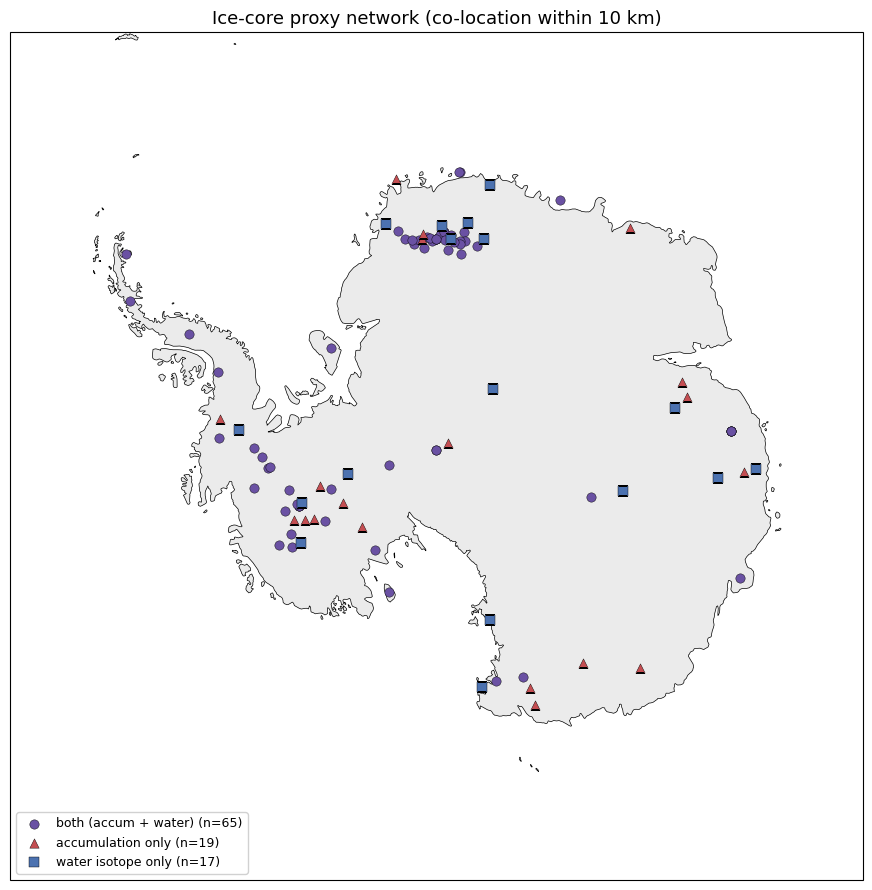

In [15]:
# --- Ice-core records: accumulation-only, water-isotope-only, co-located (both) ---
_xyz = lambda lat, lon: np.stack([np.cos(np.deg2rad(lat))*np.cos(np.deg2rad(lon)),
                                  np.cos(np.deg2rad(lat))*np.sin(np.deg2rad(lon)),
                                  np.sin(np.deg2rad(lat))], -1)
chord_km = lambda d: 2*np.arcsin(np.clip(d/2, 0, 1))*6371.0
MATCH_KM = 10.0
acc_xyz, wat_xyz = _xyz(core_lats, core_lons), _xyz(water_lats, water_lons)
acc_has_water = chord_km(cKDTree(wat_xyz).query(acc_xyz)[0]) < MATCH_KM
wat_has_acc   = chord_km(cKDTree(acc_xyz).query(wat_xyz)[0]) < MATCH_KM

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={"projection": ccrs.SouthPolarStereo()})
ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=0); ax.add_feature(cfeature.LAND, facecolor="0.92", zorder=1)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=2)
for lon, lat, c, mk, lbl in [
        (core_lons[acc_has_water], core_lats[acc_has_water], "#6A51A3", "o", "both (accum + water)"),
        (core_lons[~acc_has_water], core_lats[~acc_has_water], "#C44E52", "^", "accumulation only"),
        (water_lons[~wat_has_acc], water_lats[~wat_has_acc], "#4C72B0", "s", "water isotope only")]:
    ax.scatter(lon, lat, s=45, c=c, marker=mk, edgecolor="k", linewidth=0.3,
               transform=ccrs.PlateCarree(), zorder=3, label=f"{lbl} (n={len(lon)})")
ax.legend(loc="lower left", fontsize=9, framealpha=0.9)
ax.set_title(f"Ice-core proxy network (co-location within {MATCH_KM:.0f} km)", fontsize=13)
plt.tight_layout(); plt.show()


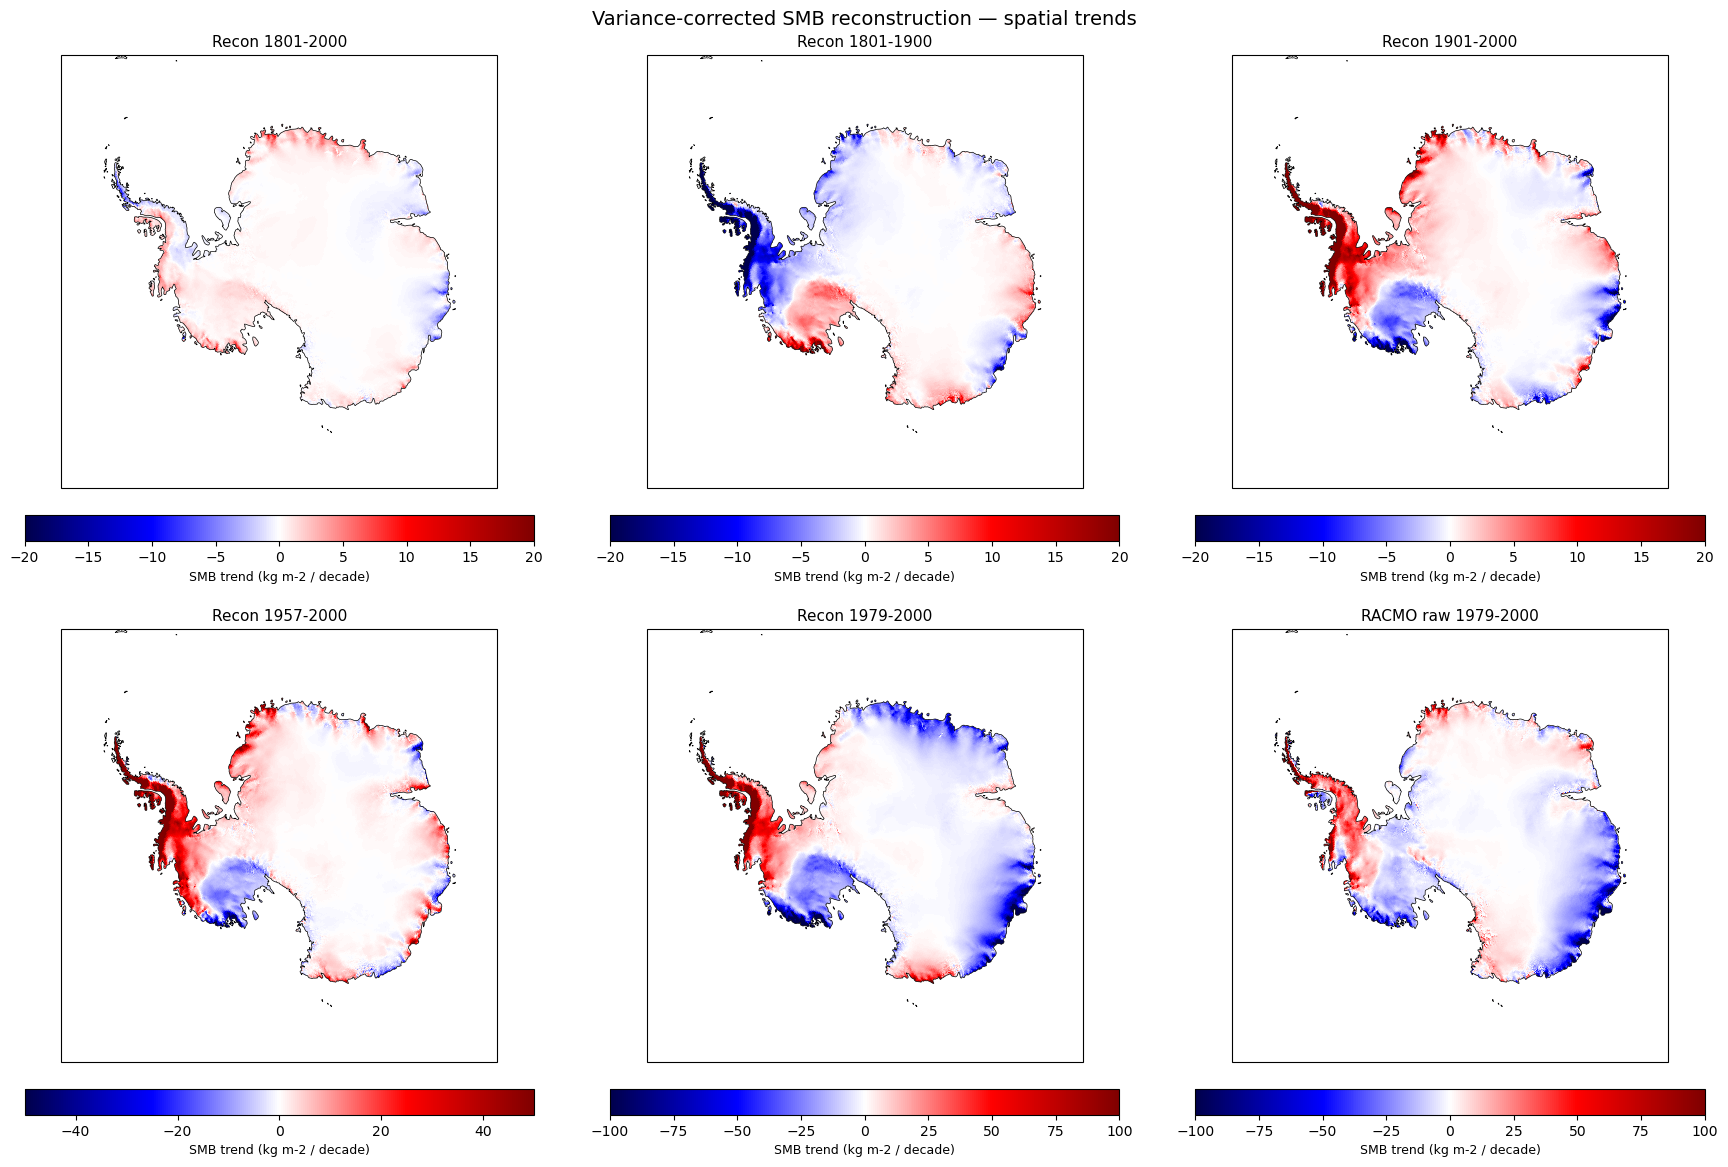

In [16]:
def spatial_trend(cube_3d, yr_start, yr_end, yr_offset=1801):
    sub = cube_3d[yr_start-yr_offset:yr_end-yr_offset+1]
    t = np.arange(sub.shape[0], dtype=float); X = np.vstack([t, np.ones_like(t)]).T
    beta, *_ = np.linalg.lstsq(X, sub.reshape(sub.shape[0], -1), rcond=None)
    return beta[0].reshape(sub.shape[1], sub.shape[2]) * 10

def six_panel(recon_cube, raw_da, cbar_label, cmap, vmaxes, suptitle):
    periods = [("Recon 1801-2000", recon_cube, 1801, 2000, vmaxes[0], 1801),
               ("Recon 1801-1900", recon_cube, 1801, 1900, vmaxes[1], 1801),
               ("Recon 1901-2000", recon_cube, 1901, 2000, vmaxes[2], 1801),
               ("Recon 1957-2000", recon_cube, 1957, 2000, vmaxes[3], 1801),
               ("Recon 1979-2000", recon_cube, 1979, 2000, vmaxes[4], 1801),
               ("RACMO raw 1979-2000", raw_da.sel(year=slice(1979,2000)).values, 1979, 2000, vmaxes[5], 1979)]
    fig, axes = plt.subplots(2, 3, figsize=(18, 12), subplot_kw={"projection": ccrs.SouthPolarStereo()})
    for ax, (title, cube, y0, y1, vmax, off) in zip(axes.ravel(), periods):
        ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
        im = ax.pcolormesh(lon_racmo, lat_racmo, spatial_trend(cube, y0, y1, off),
                           transform=ccrs.PlateCarree(), vmin=-vmax, vmax=vmax, cmap=cmap, zorder=1)
        ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=2); ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)
        ax.set_title(title, fontsize=11, pad=6)
        fig.colorbar(im, ax=ax, orientation="horizontal", pad=0.05, shrink=0.85).set_label(cbar_label, fontsize=9)
    fig.suptitle(suptitle, fontsize=14); fig.tight_layout(); plt.show()

six_panel(racmo_smb_recon, smb_ann, "SMB trend (kg m-2 / decade)", "seismic",
          [20, 20, 20, 50, 100, 100], "Variance-corrected SMB reconstruction — spatial trends")


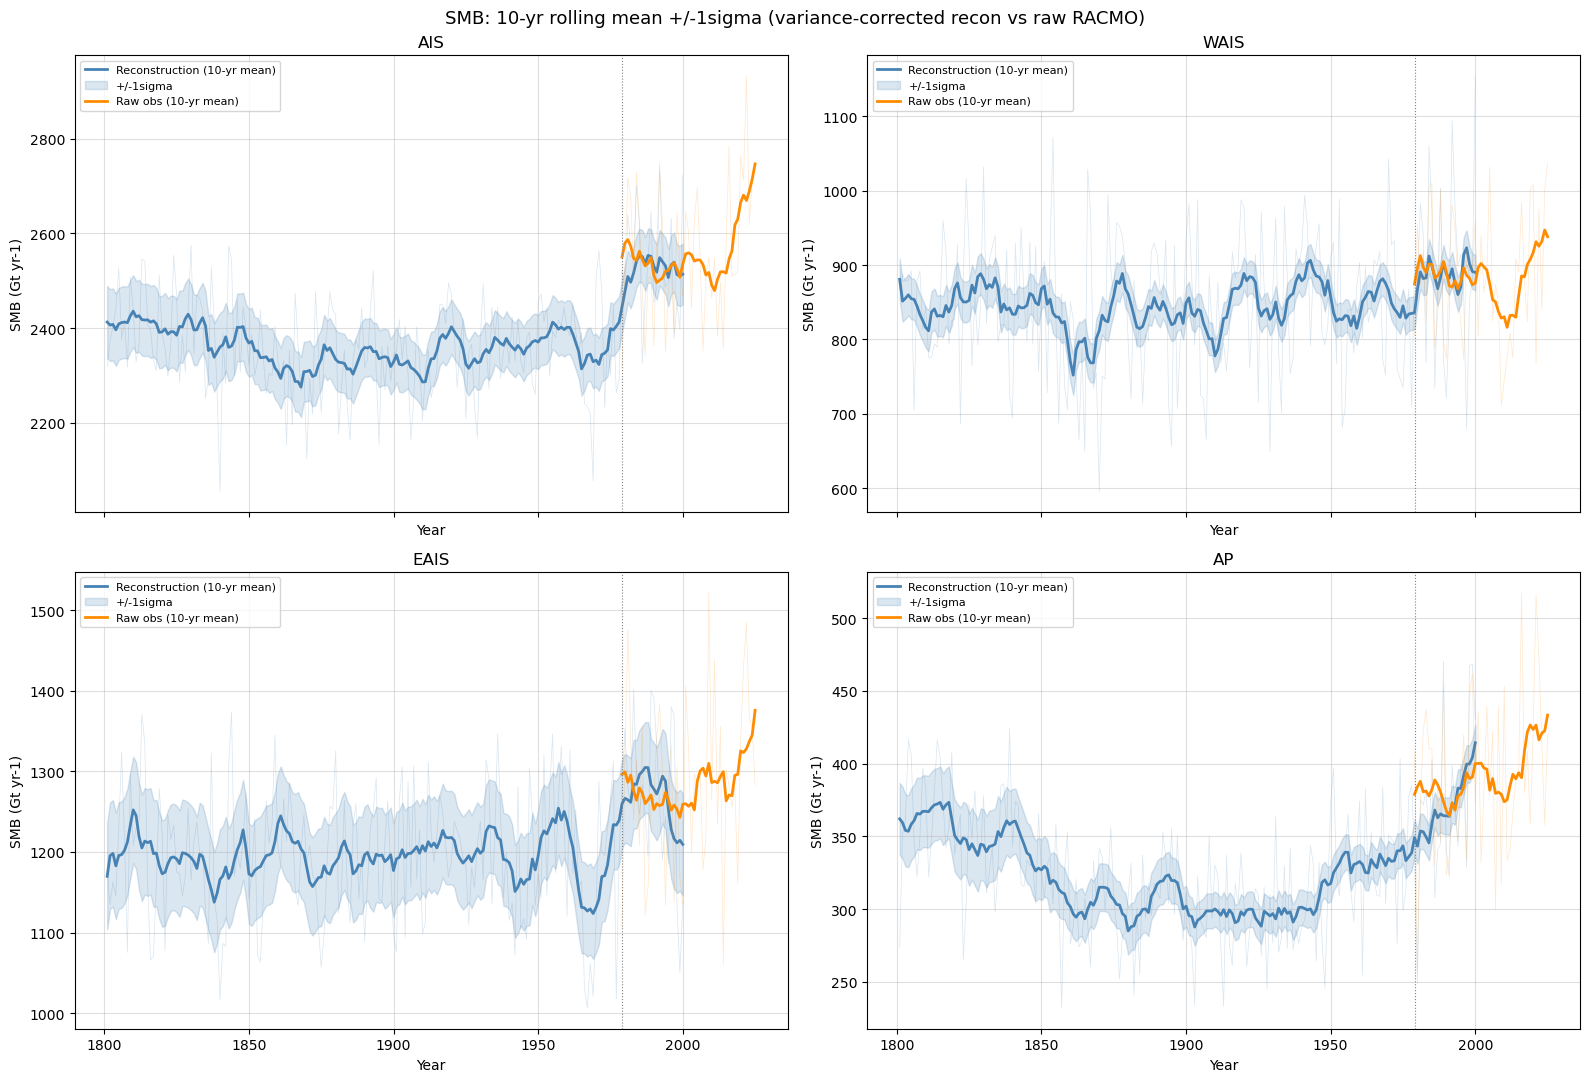

In [17]:
rolling_mean = lambda ts, w=10: pd.Series(ts).rolling(w, center=True, min_periods=1).mean().values
smb_pairs = [("AIS", ais_rac_recon, ais_rac), ("WAIS", wais_rac_recon, wais_rac),
             ("EAIS", eais_rac_recon, eais_rac), ("AP", ap_rac_recon, ap_rac)]
obs_years_plot = np.arange(1979, 2026)
fig, axes = plt.subplots(2, 2, figsize=(16, 11), sharex=True)
for ax, (region, recon_ts, obs_full) in zip(axes.ravel(), smb_pairs):
    rm = rolling_mean(recon_ts); band = rolling_mean(smb_std_by_region[region])
    ax.plot(recon_years, recon_ts, color="steelblue", lw=0.5, alpha=0.2)
    ax.plot(recon_years, rm, color="steelblue", lw=2.0, label="Reconstruction (10-yr mean)")
    ax.fill_between(recon_years, rm-band, rm+band, color="steelblue", alpha=0.2, label="+/-1sigma")
    ax.plot(obs_years_plot, np.asarray(obs_full), color="darkorange", lw=0.5, alpha=0.2)
    ax.plot(obs_years_plot, rolling_mean(np.asarray(obs_full)), color="darkorange", lw=2.0, label="Raw obs (10-yr mean)")
    ax.axvline(1979, color="gray", lw=0.8, ls=":"); ax.set_title(region)
    ax.set_ylabel("SMB (Gt yr-1)"); ax.set_xlabel("Year"); ax.legend(fontsize=8); ax.grid(alpha=0.4)
fig.suptitle("SMB: 10-yr rolling mean +/-1sigma (variance-corrected recon vs raw RACMO)", fontsize=13)
fig.tight_layout(); plt.show()


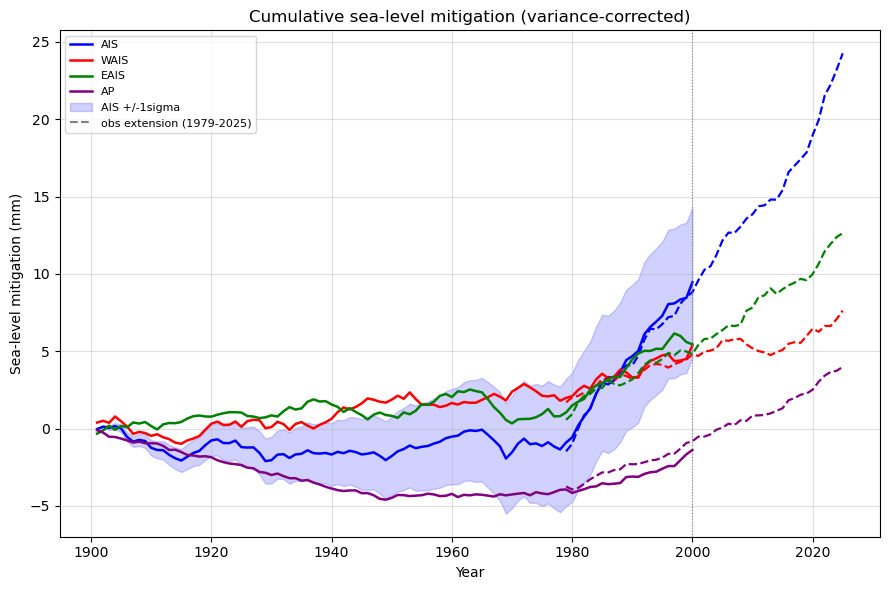

In [18]:
def sea_level_mitigation(ts, baseline=slice(0, 100)):
    return np.cumsum(ts - np.mean(ts[baseline])) / 361.8
def extend_slm(recon_ts, obs_ts, baseline=slice(0, 100)):
    base = np.mean(recon_ts[baseline]); cum = np.sum(recon_ts[:178] - base) / 361.8
    return cum + np.cumsum((np.asarray(obs_ts) - base) / 361.8)
ens = smb_reg_ens[:, :, 0]
slm_std = np.stack([sea_level_mitigation(ens[:, m]) for m in range(ens.shape[1])]).std(0, ddof=1)
slm_ais = sea_level_mitigation(ais_rac_recon); cent_years = np.arange(1901, 2001)
fig, ax = plt.subplots(figsize=(9, 6))
for recon_ts, obs_ts, name, col in [(ais_rac_recon, ais_rac, "AIS", "blue"), (wais_rac_recon, wais_rac, "WAIS", "red"),
                                    (eais_rac_recon, eais_rac, "EAIS", "green"), (ap_rac_recon, ap_rac, "AP", "purple")]:
    ax.plot(cent_years, sea_level_mitigation(recon_ts)[100:], color=col, lw=1.8, label=name)
    ax.plot(years_obs, extend_slm(recon_ts, obs_ts), color=col, lw=1.6, ls="--")
ax.fill_between(cent_years, (slm_ais-slm_std)[100:], (slm_ais+slm_std)[100:], color="blue", alpha=0.18, label="AIS +/-1sigma")
ax.plot([], [], color="gray", lw=1.5, ls="--", label="obs extension (1979-2025)")
ax.axvline(2000, color="gray", lw=0.8, ls=":"); ax.set_xlabel("Year"); ax.set_ylabel("Sea-level mitigation (mm)")
ax.set_title("Cumulative sea-level mitigation (variance-corrected)"); ax.legend(fontsize=8); ax.grid(alpha=0.4)
plt.tight_layout(); plt.show()


In [19]:
import glob
from scipy.interpolate import RegularGridInterpolator
mfiles = sorted(f for f in glob.glob(os.path.expanduser("~/DataFiles/M2TMNXFLX/*")) if f.endswith((".nc4", ".dap.nc4")))
merra_ds = xr.concat([xr.open_dataset(f) for f in mfiles], dim="time")
secs = merra_ds["time"].dt.days_in_month * 86400.0
merra_acc = ((merra_ds["PRECTOT"] * secs).groupby("time.year").sum("time").sel(year=slice(1979, 2025)))
def regrid_to_ant11(da):
    mlat, mlon, vals = da["lat"].values, da["lon"].values, da.values
    if mlat[0] > mlat[-1]: mlat = mlat[::-1]; vals = vals[:, ::-1, :]
    if mlon[0] > mlon[-1]: mlon = mlon[::-1]; vals = vals[:, :, ::-1]
    pts = np.stack([lat_racmo.ravel(), np.clip(lon_racmo.ravel(), mlon.min(), mlon.max())], -1)
    out = np.empty((vals.shape[0], NY, NX))
    for t in range(vals.shape[0]):
        out[t] = RegularGridInterpolator((mlat, mlon), vals[t], bounds_error=False, fill_value=np.nan)(pts).reshape(NY, NX)
    return xr.DataArray(out, dims=("year","rlat","rlon"), coords={"year": da["year"].values})
merra_ann = regrid_to_ant11(merra_acc); print("MERRA-2 on ANT11:", merra_ann.shape)


MERRA-2 on ANT11: (43, 591, 726)


/var/folders/4d/5th1wr_s21g614c74mcbh9kc0000gn/T/ipykernel_95374/1829690748.py:2: RuntimeWarning: Mean of empty slice
  ra = rec - np.nanmean(rec, axis=0); oa = obs - np.nanmean(obs, axis=0)
/var/folders/4d/5th1wr_s21g614c74mcbh9kc0000gn/T/ipykernel_95374/1829690748.py:2: RuntimeWarning: Mean of empty slice
  ra = rec - np.nanmean(rec, axis=0); oa = obs - np.nanmean(obs, axis=0)


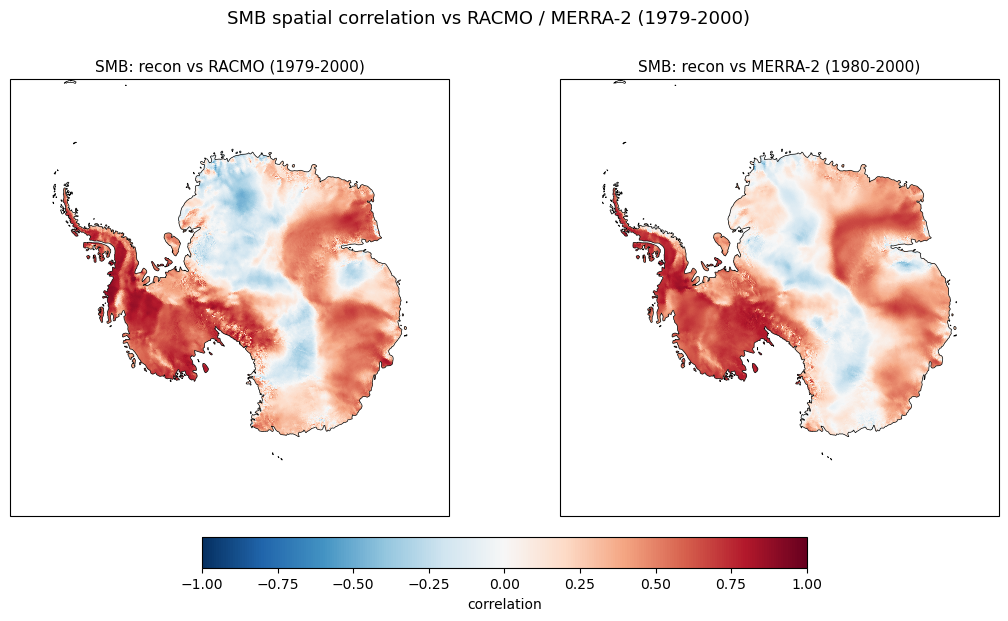

In [20]:
def spatial_corr(rec, obs):
    ra = rec - np.nanmean(rec, axis=0); oa = obs - np.nanmean(obs, axis=0)
    num = np.nansum(ra*oa, axis=0); den = np.sqrt(np.nansum(ra**2, axis=0)*np.nansum(oa**2, axis=0))
    with np.errstate(invalid="ignore"): return np.where(den > 0, num/den, np.nan)
def _align(cube, obs_da, y0=1979, y1=2000):
    yrs = [y for y in range(y0, y1+1) if y in obs_da["year"].values]
    return cube[[y-1801 for y in yrs]], obs_da.sel(year=yrs).values, (yrs[0], yrs[-1])
fig, axes = plt.subplots(1, 2, figsize=(13, 7), subplot_kw={"projection": ccrs.SouthPolarStereo()})
im = None
for ax, (src, da) in zip(axes, [("RACMO", smb_ann), ("MERRA-2", merra_ann)]):
    rec, obs, (ya, yb) = _align(racmo_smb_recon, da)
    ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
    im = ax.pcolormesh(lon_racmo, lat_racmo, spatial_corr(rec, obs), transform=ccrs.PlateCarree(),
                       vmin=-1, vmax=1, cmap="RdBu_r", zorder=1)
    ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=2); ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)
    ax.set_title(f"SMB: recon vs {src} ({ya}-{yb})", fontsize=11)
fig.colorbar(im, ax=axes, orientation="horizontal", pad=0.04, shrink=0.6).set_label("correlation")
fig.suptitle("SMB spatial correlation vs RACMO / MERRA-2 (1979-2000)", fontsize=13); plt.show()


In [21]:
grace = xr.open_dataset(os.path.expanduser("~/DataFiles/GRCTellus.JPL.200204_202604.GLO.RL06.3M.MSCNv04CRI.nc"))
gsub = grace["lwe_thickness"].sel(lat=slice(-90, -60)); glat = gsub["lat"].values; glon = gsub["lon"].values; ewh = gsub.values
Rm = 6371000.0
gcell = (Rm*Rm*np.deg2rad(0.5)*(np.sin(np.deg2rad(glat+0.25))-np.sin(np.deg2rad(glat-0.25))))[:, None]*np.ones((1, len(glon)))
glon2d, glat2d = np.meshgrid(glon, glat); gidf = basin_mask[ice_sheet]
d, ii = cKDTree(to_xyz(lat_racmo[ice_sheet], lon_racmo[ice_sheet])).query(to_xyz(glat2d.ravel(), glon2d.ravel()))
near_basin = np.where(d*6371.0 < 150, gidf[ii], 0).reshape(glat2d.shape)
grace_masks = {"AIS": near_basin > 0, "WAIS": np.isin(near_basin, [3,7,8,9,10]),
               "EAIS": np.isin(near_basin, [1,2,11,12,13,14,15,16,17,18]), "AP": np.isin(near_basin, [4,5,6])}
gyear = pd.DatetimeIndex(grace["time"].values).year
def grace_annual(mask):
    m = np.array([np.nansum(np.where(mask, ewh[t]*gcell*10/1e12, 0)) for t in range(ewh.shape[0])])
    return pd.Series(m, index=gyear).groupby(level=0).mean()
print("GRACE ready:", ewh.shape)


GRACE ready: (256, 60, 720)


Region    GRACE      SMB     dyn
AIS      -114.7    200.1  -314.8
WAIS     -158.3     27.3  -185.6
EAIS       68.5    104.1   -35.7
AP        -24.8     68.7   -93.5


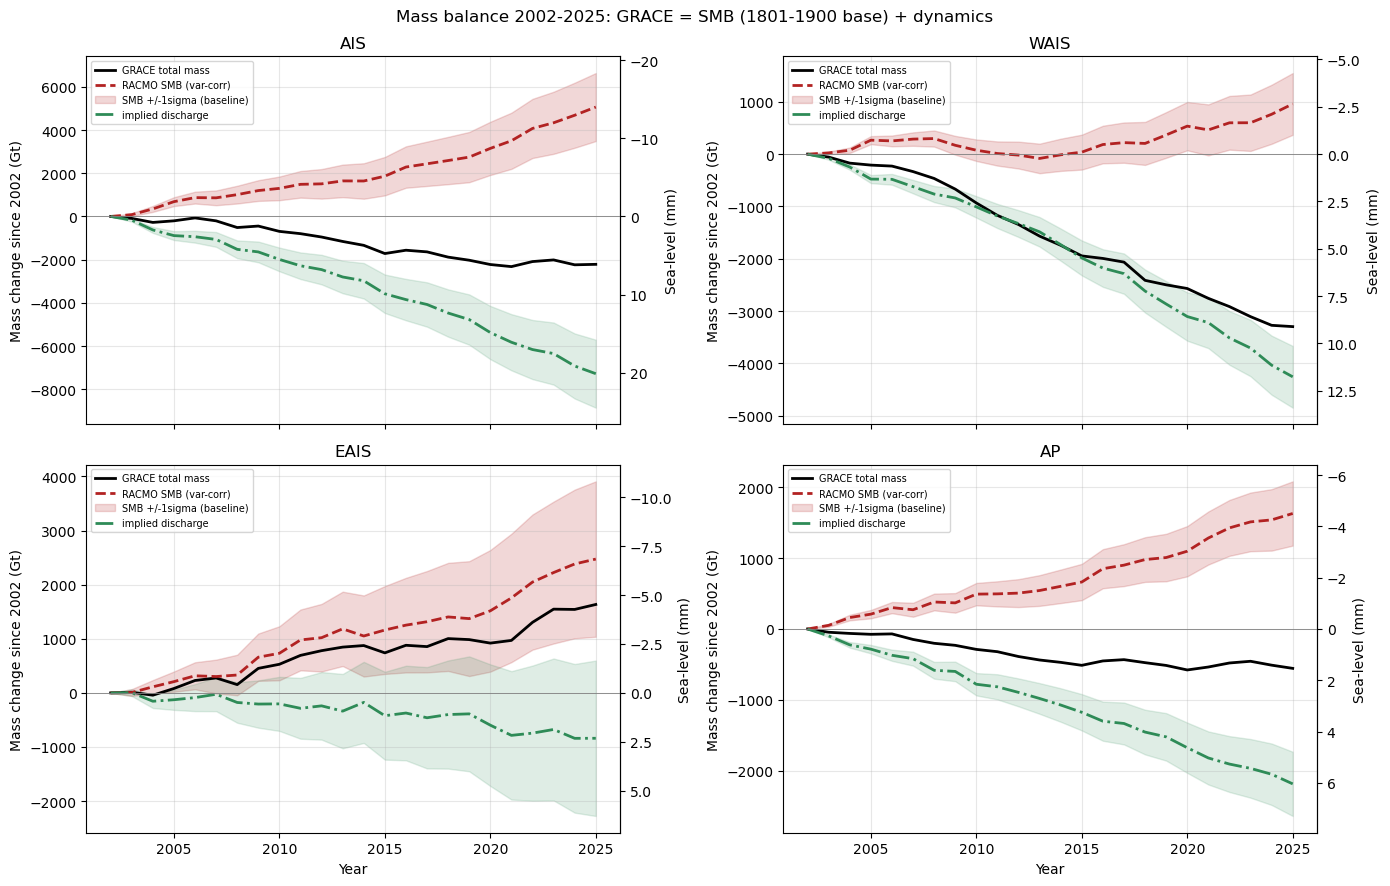

In [22]:
BASELINE = (1801, 1900); GT_PER_MM = 361.8; region_idx = {"AIS":0,"WAIS":1,"EAIS":2,"AP":3}
def combined_smb(r):
    return pd.concat([pd.Series(recon_series[r], index=recon_years).loc[:1978], raw_series[r].loc[1979:]])
def baseline_error(r):
    k = region_idx[r]; yb = [y for y in range(BASELINE[0], BASELINE[1]+1) if y <= 2000]
    return smb_reg_ens[[y-1801 for y in yb], :, k].mean(axis=0).std(ddof=1) if yb else 0.0
yrs = np.arange(2002, 2026)
zeroed = lambda s: s.reindex(yrs) - s.reindex(yrs).loc[2002]
trend  = lambda s: (np.polyfit(yrs.astype(float)[np.isfinite(s.reindex(yrs).values)],
                    s.reindex(yrs).values[np.isfinite(s.reindex(yrs).values)], 1)[0])
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
print(f"{'Region':<6}{'GRACE':>9}{'SMB':>9}{'dyn':>8}")
for ax, r in zip(axes.ravel(), region_names):
    comb = combined_smb(r); base = comb.loc[BASELINE[0]:BASELINE[1]].mean(); sig_base = baseline_error(r)
    g = zeroed(grace_annual(grace_masks[r])); c = zeroed((comb-base).loc[2002:2025].cumsum()); dyn = g - c
    c_err = np.arange(len(yrs))*sig_base
    ax.plot(yrs, g.values, color="black", lw=2, label="GRACE total mass")
    ax.plot(yrs, c.values, color="firebrick", lw=2, ls="--", label="RACMO SMB (var-corr)")
    ax.fill_between(yrs, c.values-c_err, c.values+c_err, color="firebrick", alpha=0.18, label="SMB +/-1sigma (baseline)")
    ax.plot(yrs, dyn.values, color="seagreen", lw=2, ls="-.", label="implied discharge")
    ax.fill_between(yrs, dyn.values-c_err, dyn.values+c_err, color="seagreen", alpha=0.15)
    ax.axhline(0, color="gray", lw=0.6); ax.set_title(r); ax.set_ylabel("Mass change since 2002 (Gt)")
    ax.legend(fontsize=7); ax.grid(alpha=0.3)
    ax.secondary_yaxis("right", functions=(lambda m: -m/GT_PER_MM, lambda s: -s*GT_PER_MM)).set_ylabel("Sea-level (mm)")
    print(f"{r:<6}{trend(g):>9.1f}{trend(c):>9.1f}{trend(dyn):>8.1f}")
for ax in axes[-1, :]: ax.set_xlabel("Year")
fig.suptitle(f"Mass balance 2002-2025: GRACE = SMB ({BASELINE[0]}-{BASELINE[1]} base) + dynamics", fontsize=12)
fig.tight_layout(); plt.show()


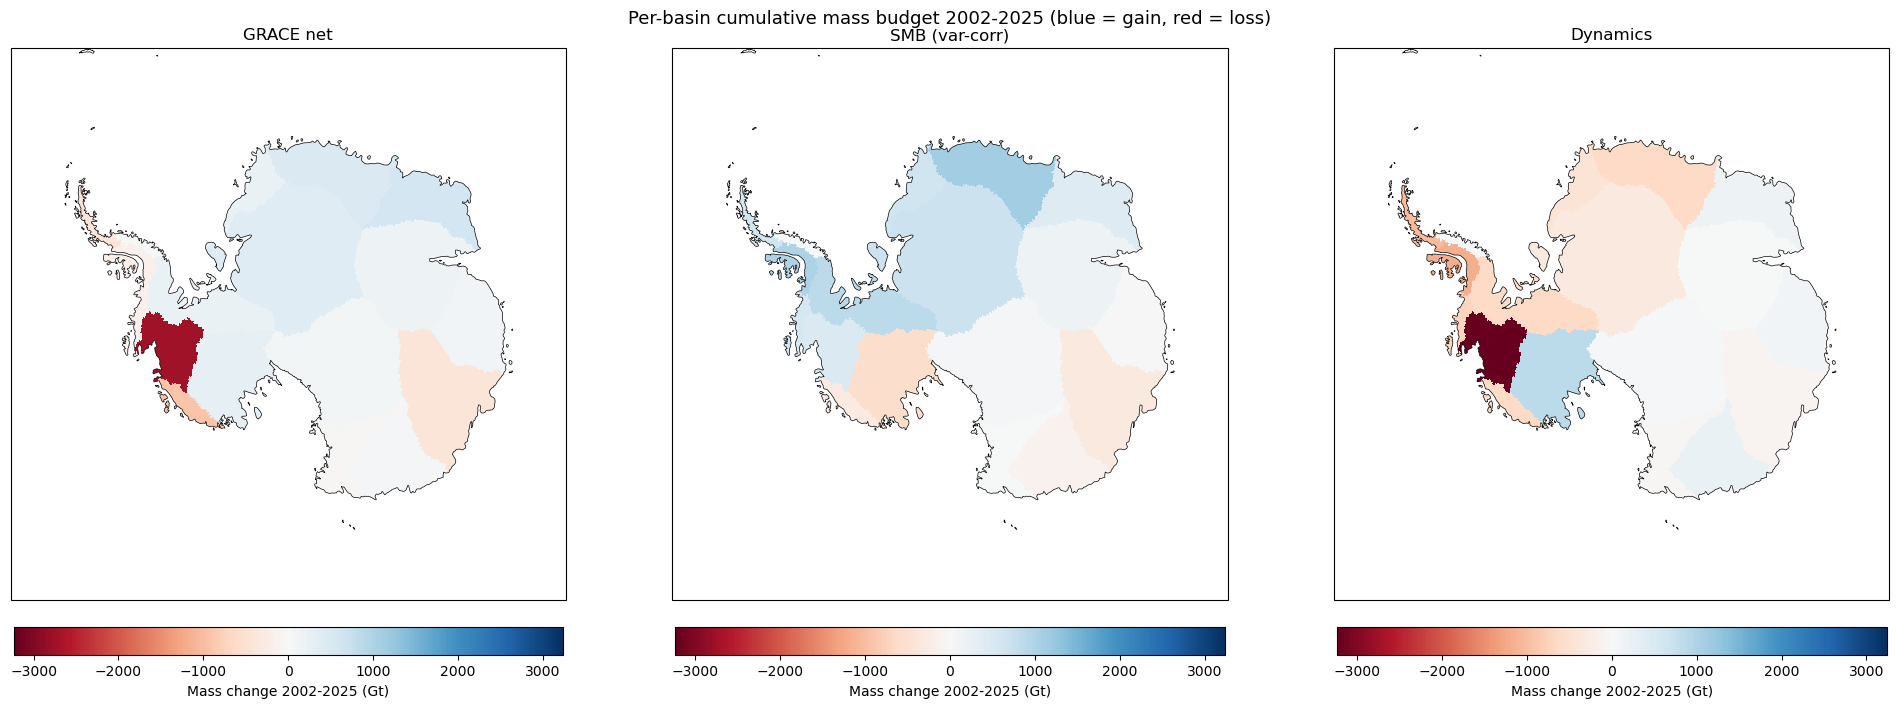

In [23]:
y0, y1 = 2002, 2025; dM_grace, dM_smb, dM_dyn = {}, {}, {}
for bid in basin_ids_unique:
    gmask = near_basin == bid
    if gmask.sum() == 0: dM_grace[bid] = np.nan
    else:
        m = np.array([np.nansum(np.where(gmask, ewh[t]*gcell*10/1e12, 0)) for t in range(ewh.shape[0])])
        gm = pd.Series(m, index=gyear).groupby(level=0).mean(); dM_grace[bid] = gm.get(y1, np.nan) - gm.get(y0, np.nan)
    rmask = basin_mask == bid
    smb = pd.Series([np.nansum(np.where(rmask, smb_ann.values[t]*cell_area_m2, 0))/1e12 for t in range(len(years_obs))], index=years_obs)
    comb = pd.concat([smb_basin_recon[bid].loc[:1978], smb.loc[1979:]]); base = comb.loc[1801:1900].mean()
    dM_smb[bid] = (smb.loc[y0:y1] - base).sum(); dM_dyn[bid] = dM_grace[bid] - dM_smb[bid]
def paint(dct):
    f = np.full(basin_mask.shape, np.nan)
    for bid, v in dct.items(): f[basin_mask == bid] = v
    return f
vmax = np.nanmax(np.abs(list(dM_grace.values())+list(dM_smb.values())+list(dM_dyn.values())))
fig, axes = plt.subplots(1, 3, figsize=(20, 7.5), subplot_kw={"projection": ccrs.SouthPolarStereo()})
for ax, (title, dct) in zip(axes, [("GRACE net", dM_grace), ("SMB (var-corr)", dM_smb), ("Dynamics", dM_dyn)]):
    ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
    im = ax.pcolormesh(lon_racmo, lat_racmo, paint(dct), transform=ccrs.PlateCarree(), vmin=-vmax, vmax=vmax, cmap="RdBu", zorder=1)
    ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=2); ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)
    ax.set_title(title, fontsize=12, pad=6)
    fig.colorbar(im, ax=ax, orientation="horizontal", pad=0.04, shrink=0.85).set_label("Mass change 2002-2025 (Gt)")
fig.suptitle("Per-basin cumulative mass budget 2002-2025 (blue = gain, red = loss)", fontsize=13)
plt.tight_layout(); plt.show()


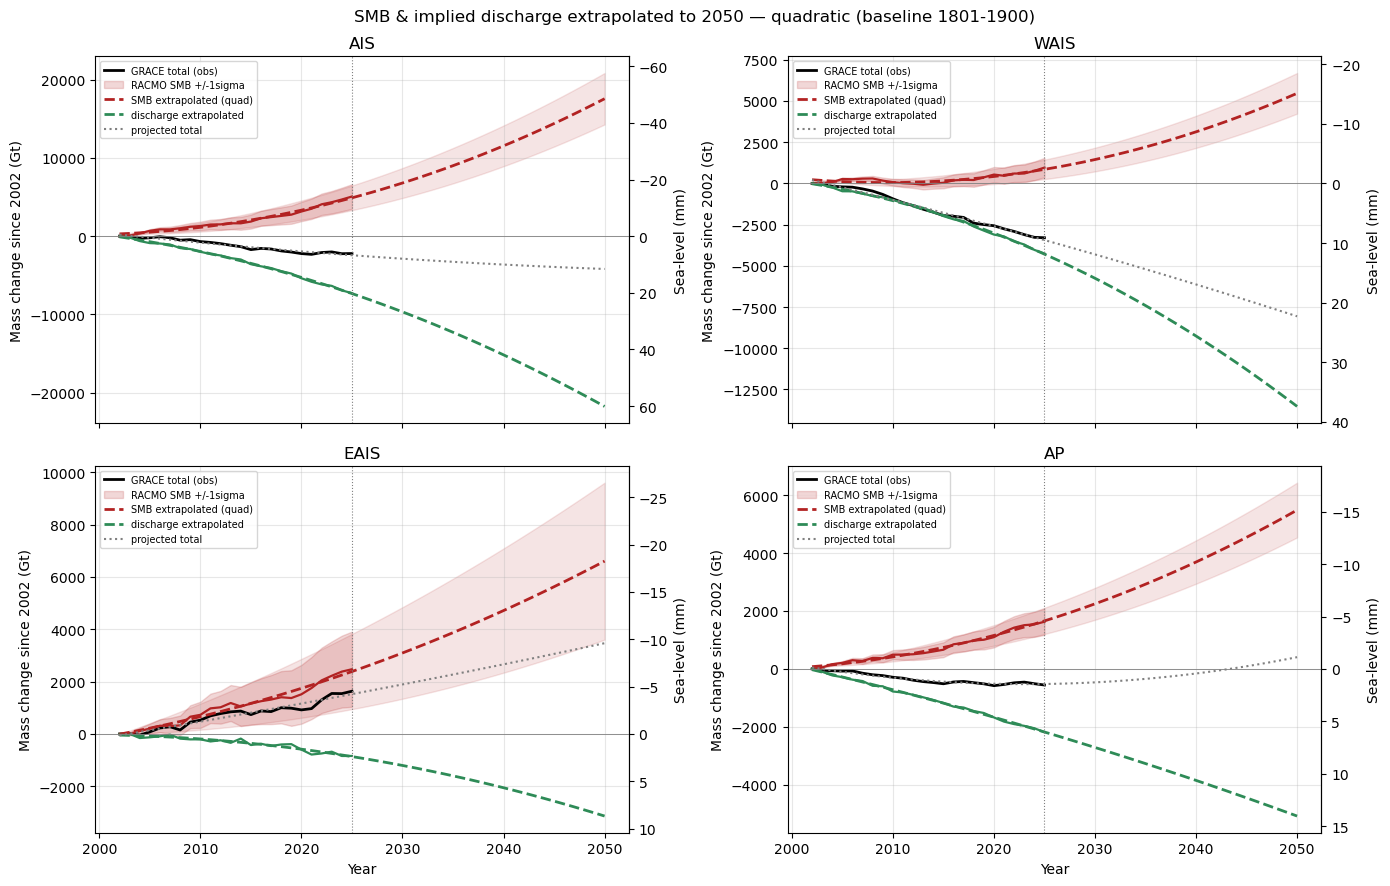

In [24]:
TARGET_YEAR = 2050
def baseline_mean(r):
    comb = pd.concat([pd.Series(recon_series[r], index=recon_years).loc[:1978], raw_series[r].loc[1979:]])
    return comb.loc[1801:1900].mean()
hist = np.arange(2002, 2026); fut = np.arange(2002, TARGET_YEAR+1)
t = (hist-2002).astype(float); tf = (fut-2002).astype(float)
proj2 = lambda y: np.polyval(np.polyfit(t[np.isfinite(y)], y[np.isfinite(y)], 2), tf)
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
for ax, r in zip(axes.ravel(), region_names):
    g = grace_annual(grace_masks[r]).reindex(hist); black = (g - g.loc[2002]).values
    rc = (raw_series[r] - baseline_mean(r)).loc[2002:2025].cumsum(); red = (rc - rc.loc[2002]).reindex(hist).values
    green = black - red; red_ext, green_ext = proj2(red), proj2(green)
    sig_base = baseline_error(r); err_h = (hist-2002)*sig_base; err_f = (fut-2002)*sig_base
    ax.plot(hist, black, "k-", lw=2, label="GRACE total (obs)")
    ax.plot(hist, red, color="firebrick", lw=1.6)
    ax.fill_between(hist, red-err_h, red+err_h, color="firebrick", alpha=0.18, label="RACMO SMB +/-1sigma")
    ax.plot(hist, green, color="seagreen", lw=1.6)
    ax.plot(fut, red_ext, "--", color="firebrick", lw=2, label="SMB extrapolated (quad)")
    ax.fill_between(fut, red_ext-err_f, red_ext+err_f, color="firebrick", alpha=0.12)
    ax.plot(fut, green_ext, "--", color="seagreen", lw=2, label="discharge extrapolated")
    ax.plot(fut, red_ext+green_ext, ":", color="gray", lw=1.5, label="projected total")
    ax.axvline(2025, color="gray", lw=0.8, ls=":"); ax.axhline(0, color="gray", lw=0.6)
    ax.set_title(r); ax.set_ylabel("Mass change since 2002 (Gt)"); ax.legend(fontsize=7); ax.grid(alpha=0.3)
    ax.secondary_yaxis("right", functions=(lambda m: -m/GT_PER_MM, lambda s: -s*GT_PER_MM)).set_ylabel("Sea-level (mm)")
for ax in axes[-1, :]: ax.set_xlabel("Year")
fig.suptitle(f"SMB & implied discharge extrapolated to {TARGET_YEAR} — quadratic (baseline 1801-1900)", fontsize=12)
fig.tight_layout(); plt.show()


reg   kappa    ToE
AIS    0.00   2001
WAIS   0.00   None
EAIS   0.00   2011
AP     0.63   None


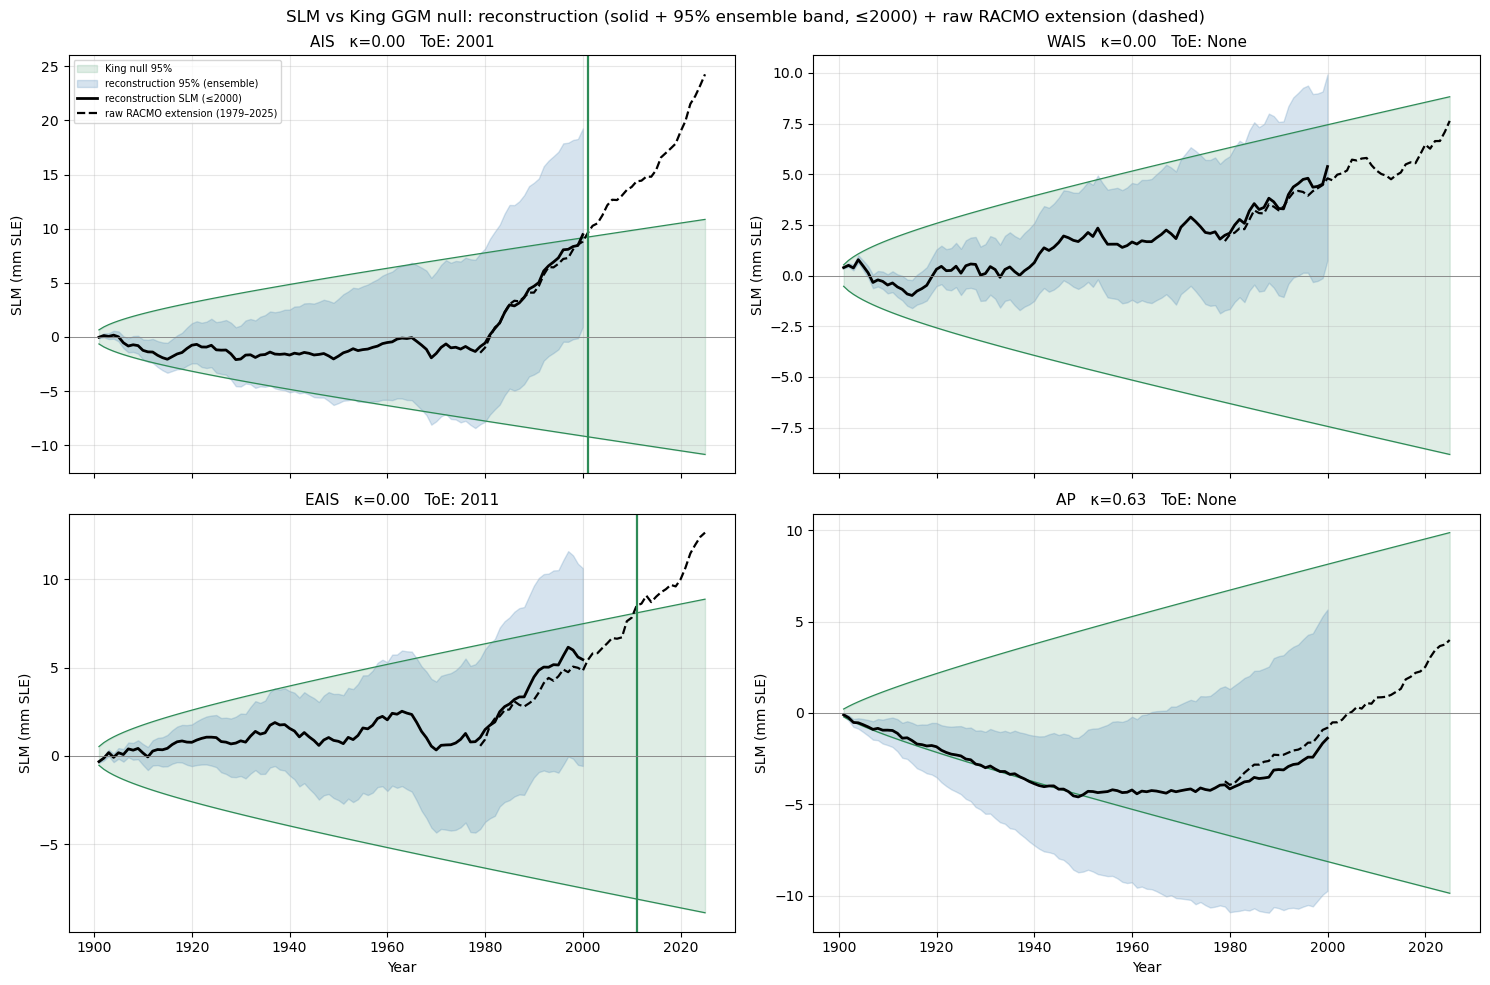

In [25]:
from scipy.stats import norm
GT, NB, NA = 361.8, 100, 125
def slm_sigma(fit):
    R = _toeplitz(_ggm_acf(fit["kappa"], fit["phi"], NB+NA) * fit["sigma_w"]**2)
    return np.array([np.sqrt((a := np.concatenate([np.full(NB,-n/NB),np.ones(n)])) @ R[:NB+n,:NB+n] @ a)/GT
                     for n in range(1, NA+1)])
def slm_cum(ts, base=slice(0,100)):
    ts = np.asarray(ts); return np.cumsum(ts - np.mean(ts[base])) / GT
def extend_slm(recon_ts, obs_ts, base=slice(0,100)):
    r = np.asarray(recon_ts); b = np.mean(r[base]); cum = np.sum(r[:178] - b) / GT
    return cum + np.cumsum((np.asarray(obs_ts) - b) / GT)
def emergence(traj, sig, yy):
    out = traj > 1.96*sig
    for i in range(len(yy)):
        if out[i:].all(): return int(yy[i])
    return None

years = np.arange(1901, 2026); cent = np.arange(1901, 2001); yr_obs = np.arange(1979, 2026)
fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True)
print(f"{'reg':4s}{'kappa':>7s}{'ToE':>7s}")
for ax, (k, r) in zip(axes.ravel(), enumerate(region_names)):
    recon_ts  = np.asarray(recon_series[r])                       # King-corrected posterior mean, 1801-2000
    slm_recon = slm_cum(recon_ts)
    ens = smb_reg_ens[:, :, k]                                    # corrected regional ensemble
    slm_mem = np.stack([slm_cum(ens[:, m]) for m in range(ens.shape[1])])
    lo, hi = np.percentile(slm_mem, [2.5, 97.5], axis=0)         # 95% reconstruction band
    slm_ext = extend_slm(recon_ts, raw_series[r].loc[1979:2025].values)
    comb = pd.concat([pd.Series(recon_ts, index=recon_years).loc[:1978],
                      raw_series[r].loc[1979:2025]]).loc[1801:2025].values
    slm_obs = np.cumsum(comb[NB:] - comb[:NB].mean()) / GT
    sig = slm_sigma(ggm_fits[r]); toe = emergence(slm_obs, sig, years)

    ax.fill_between(years, -1.96*sig, 1.96*sig, color="seagreen", alpha=0.15, label="King null 95%")
    ax.plot(years, 1.96*sig, color="seagreen", lw=0.9); ax.plot(years, -1.96*sig, color="seagreen", lw=0.9)
    ax.fill_between(cent, lo[100:200], hi[100:200], color="steelblue", alpha=0.22, label="reconstruction 95% (ensemble)")
    ax.plot(cent, slm_recon[100:200], color="k", lw=2, label="reconstruction SLM (≤2000)")   # solid black recon
    ax.plot(yr_obs, slm_ext, color="k", lw=1.6, ls="--", label="raw RACMO extension (1979–2025)")
    if toe: ax.axvline(toe, color="seagreen", lw=1.6)
    ax.axhline(0, color="gray", lw=0.6)
    ax.set_title(f"{r}   κ={ggm_fits[r]['kappa']:.2f}   ToE: {toe}", fontsize=11)
    ax.set_ylabel("SLM (mm SLE)"); ax.grid(alpha=0.3)
    if k == 0: ax.legend(fontsize=7)
    print(f"{r:4s}{ggm_fits[r]['kappa']:7.2f}{str(toe):>7s}")
for ax in axes[-1, :]: ax.set_xlabel("Year")
fig.suptitle("SLM vs King GGM null: reconstruction (solid + 95% ensemble band, ≤2000) + raw RACMO extension (dashed)",
             fontsize=12)
fig.tight_layout(); plt.show()


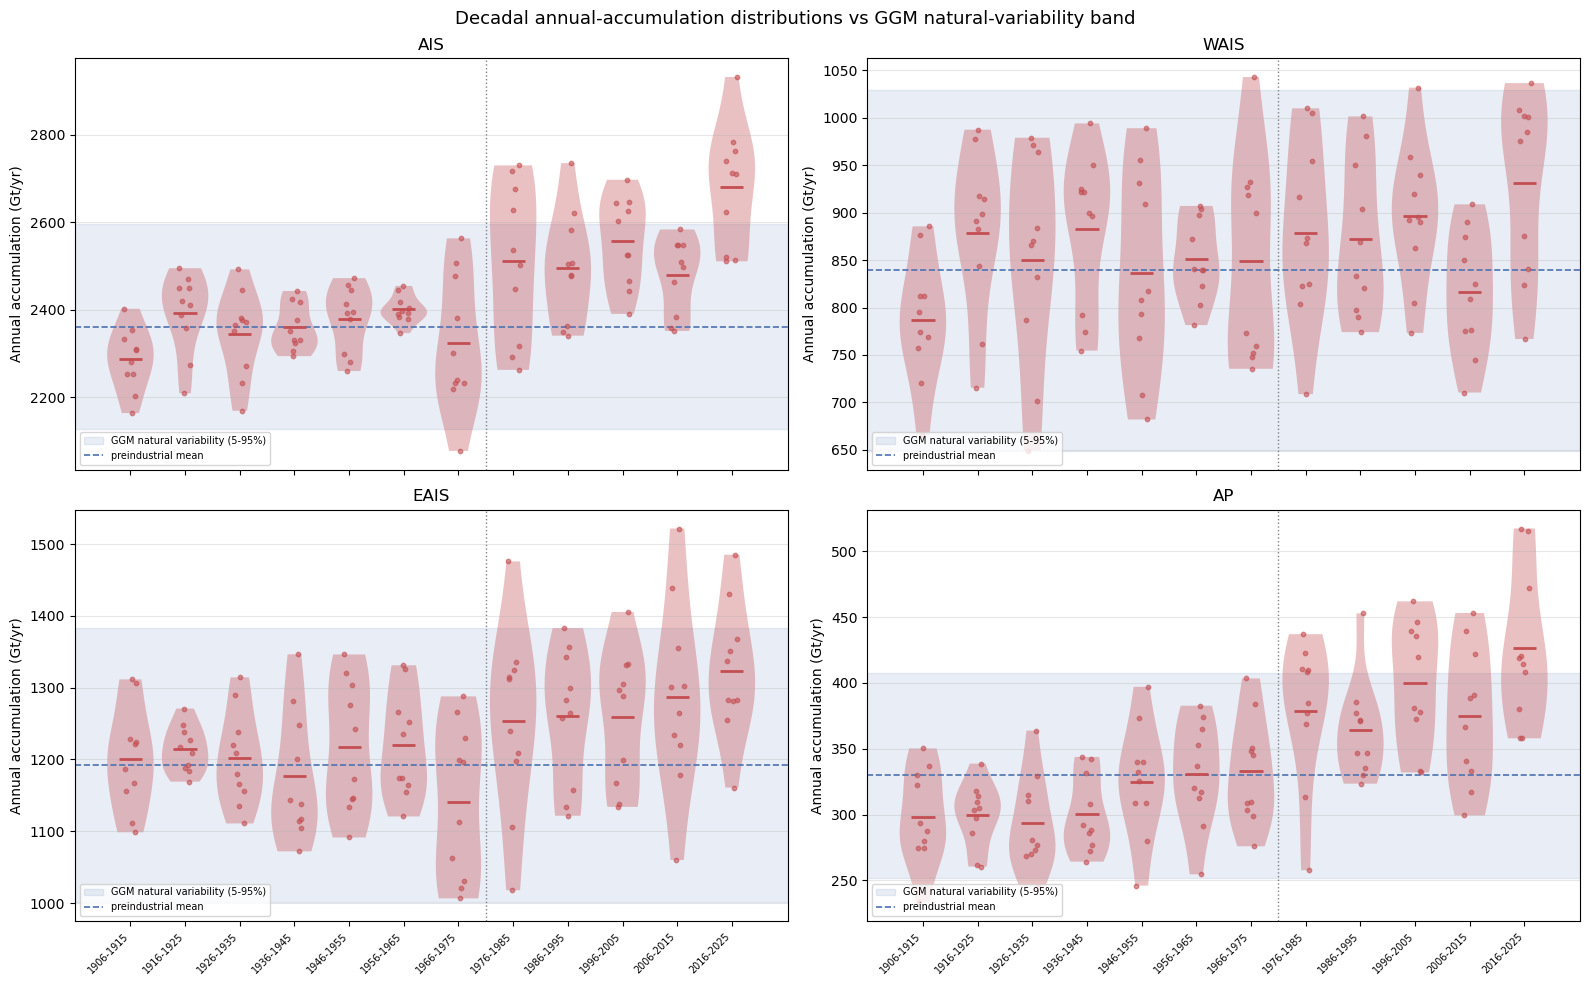

In [26]:
rng = np.random.default_rng(0); NULL_C, OBS_C = "#4C72B0", "#C44E52"
def combined(r):
    return pd.concat([pd.Series(recon_series[r], index=recon_years).loc[:1978], raw_series[r].loc[1979:]])
starts = list(range(1906, 2017, 10)); decades = [(s, s+9) for s in starts]; labels = [f"{s}-{s+9}" for s in starts]
split_x = next(i for i, (a, b) in enumerate(decades) if b >= 1979) - 0.5
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
for ax, r in zip(axes.ravel(), region_names):
    comb = combined(r); base = comb.loc[1801:1900].mean(); fit = ggm_fits[r]
    sd = np.sqrt(_ggm_acf(fit["kappa"], fit["phi"], 1)[0] * fit["sigma_w"]**2)
    ax.axhspan(base-1.96*sd, base+1.96*sd, color=NULL_C, alpha=0.12, label="GGM natural variability (5-95%)")
    ax.axhline(base, color=NULL_C, ls="--", lw=1.2, label="preindustrial mean"); ax.axvline(split_x, color="0.5", ls=":", lw=1.0)
    data = [comb.loc[a:b].values for (a, b) in decades]; xpos = np.arange(len(decades))
    vp = ax.violinplot(data, positions=xpos, widths=0.85, showmeans=True, showextrema=False)
    for body in vp["bodies"]: body.set_facecolor(OBS_C); body.set_alpha(0.35)
    vp["cmeans"].set_color(OBS_C); vp["cmeans"].set_linewidth(2)
    for i, v in enumerate(data): ax.scatter(i + rng.uniform(-0.12, 0.12, len(v)), v, s=10, color=OBS_C, alpha=0.6, zorder=3)
    ax.set_title(r); ax.set_ylabel("Annual accumulation (Gt/yr)")
    ax.set_xticks(xpos); ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
    ax.legend(fontsize=7, loc="lower left"); ax.grid(axis="y", alpha=0.3)
fig.suptitle("Decadal annual-accumulation distributions vs GGM natural-variability band", fontsize=13)
fig.tight_layout(); plt.show()


Derwael Ice Rise: core #76   lat -70.25°S   lon 26.34°E
H72: core #77   lat -69.20°S   lon 41.08°E


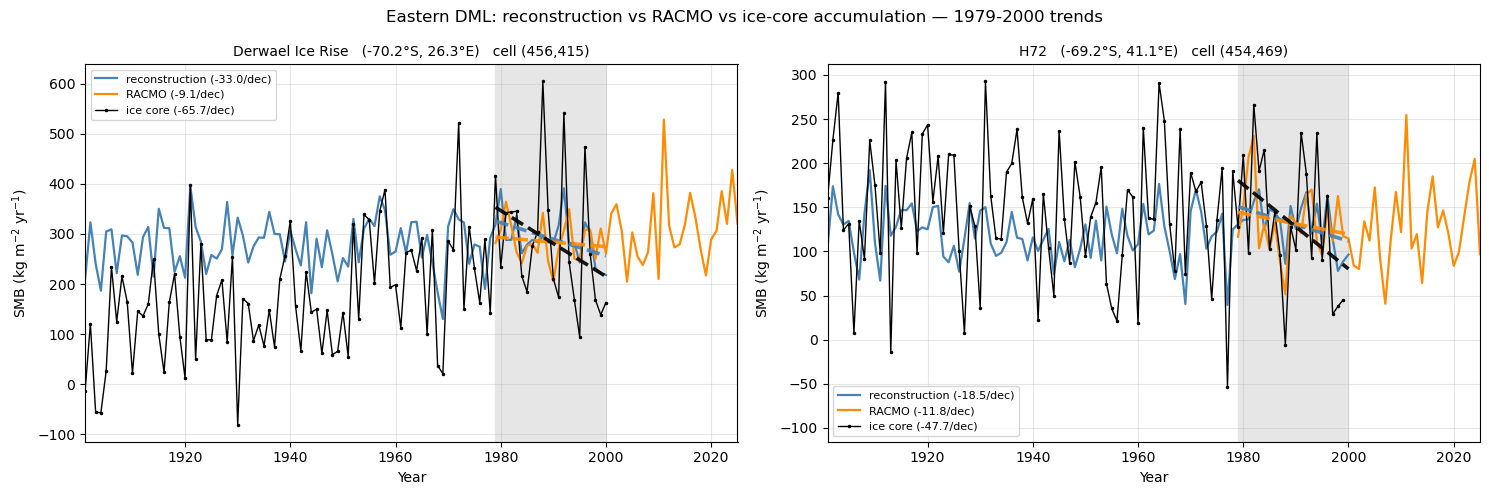

In [29]:
# --- Eastern DML cores: Derwael Ice Rise (~26.34E) and H72 (~41.08E) ---
targets = [("Derwael Ice Rise", 26.34), ("H72", 41.08)]
lon_c = ((core_lons + 180) % 360) - 180
def nearest_core(target_lon, tol=2.5):
    cand = np.where(np.abs(lon_c - target_lon) < tol)[0]
    cand = cand if len(cand) else np.arange(len(lon_c))
    return cand[np.argmin(np.abs(lon_c[cand] - target_lon))]
sel = [(name, nearest_core(lon)) for name, lon in targets]
for name, i in sel:
    print(f"{name}: core #{i}   lat {core_lats[i]:.2f}°S   lon {lon_c[i]:.2f}°E")

def trend_1979_2000(s):
    seg = s.loc[1979:2000].dropna()
    if len(seg) < 3: return np.nan, None, None
    x = seg.index.values.astype(float); a, b = np.polyfit(x, seg.values, 1)
    xe = np.array([1979.0, 2000.0]); return a, xe, a*xe + b

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True, squeeze=False)
for ax, (name, i) in zip(axes.ravel(), sel):
    j, k = nearest_ij(lat_racmo, lon_racmo, core_lats[i], core_lons[i])
    racmo_ts = pd.Series(smb_ann.values[:, j, k], index=years_obs)
    recon_ts = pd.Series(racmo_smb_recon[:, j, k], index=recon_years)
    core     = pd.Series(accum_cores_full[:, i], index=recon_years)
    ov = [y for y in range(1979, 2001) if np.isfinite(core.get(y, np.nan)) and y in racmo_ts.index]
    off = core.loc[ov].mean() - racmo_ts.loc[ov].mean() if ov else 0.0
    core_smb = core - off
    ax.axvspan(1979, 2000, color="0.9", zorder=0)
    for s, col, nm, lw, mk in [(recon_ts, "steelblue", "reconstruction", 1.6, None),
                               (racmo_ts, "darkorange", "RACMO", 1.6, None),
                               (core_smb, "k", "ice core", 1.0, ".")]:
        a, xe, ye = trend_1979_2000(s)
        lbl = f"{nm} ({a*10:+.1f}/dec)" if np.isfinite(a) else nm
        ax.plot(s.index, s.values, color=col, lw=lw, marker=mk, ms=3, label=lbl)
        if xe is not None: ax.plot(xe, ye, color=col, lw=2.6, ls="--", alpha=0.9, zorder=5)
    ax.set_title(f"{name}   ({core_lats[i]:.1f}°S, {lon_c[i]:.1f}°E)   cell ({j},{k})", fontsize=10)
    ax.set_ylabel("SMB (kg m$^{-2}$ yr$^{-1}$)"); ax.set_xlabel("Year")
    ax.grid(alpha=0.3); ax.set_xlim(1901, 2025); ax.legend(fontsize=8)
fig.suptitle("Eastern DML: reconstruction vs RACMO vs ice-core accumulation — 1979-2000 trends", fontsize=12)
fig.tight_layout(); plt.show()




In [30]:
import numpy as np, matplotlib.pyplot as plt, matplotlib.colors as mcolors
from matplotlib.patches import Patch
region_names = ["AIS","WAIS","EAIS","AP"]
raw = {"AIS": ais_rac, "WAIS": wais_rac, "EAIS": eais_rac, "AP": ap_rac}
dstd = lambda x: np.std(np.asarray(x,float)-np.polyval(np.polyfit(np.arange(len(x)),np.asarray(x,float),1),
                                                       np.arange(len(x))), ddof=1)
tint = lambda c, f: tuple(1-(1-v)*f for v in mcolors.to_rgb(c))
reg_mean = smb_reg_ens.mean(1); reg_var = smb_reg_ens.var(1, ddof=1)
PI, MOD = slice(0, 100), slice(178, 200)

# --- every bar value computed ONCE ---
V = {}
for per, sl in [("PI", PI), ("MOD", MOD)]:
    V[(per,"base")] = np.array([dstd(reg_mean[sl,k]) for k in range(4)])
    V[(per,"King")] = np.array([dstd(recon_king_reg[r][sl]) for r in region_names])
    V[(per,"LTV")]  = np.array([np.sqrt(dstd(reg_mean[sl,k])**2 + reg_var[sl,k].mean()) for k in range(4)])
V[("MOD","raw")] = np.array([dstd(raw[r].loc[1979:2000].values) for r in region_names])

print("region  base/raw  King/raw  LTV/raw   (modern 1979-2000; annotated values)")
for k, r in enumerate(region_names):
    rawM = V[("MOD","raw")][k]
    print(f"{r:5s}   {V[('MOD','base')][k]/rawM:5.2f}    {V[('MOD','King')][k]/rawM:5.2f}    {V[('MOD','LTV')][k]/rawM:5.2f}")

# --- plot from the SAME dict ---
src_col = {"base":"#8a8a8a","King":"seagreen","LTV":"#4C72B0","raw":"k"}
PI_F, MOD_F = 0.42, 1.0
layout = [("PI","base"),("PI","King"),("PI","LTV"),("MOD","base"),("MOD","King"),("MOD","LTV"),("MOD","raw")]
bw, gap = 0.1, 0.08
offs, x0 = [], -0.5*(7*bw+gap)
for i, _ in enumerate(layout):
    if i == 3: x0 += gap
    offs.append(x0 + bw/2); x0 += bw
offs = np.array(offs); sep = (offs[2]+offs[3])/2

fig, ax = plt.subplots(figsize=(14, 6.8))
for k in range(4): ax.axvline(k + sep, color="0.85", lw=1.0, zorder=0)
for i, (p, s) in enumerate(layout):
    ax.bar(np.arange(4)+offs[i], V[(p,s)], bw, color=tint(src_col[s], PI_F if p=="PI" else MOD_F),
           edgecolor="0.35", linewidth=0.4)
for k in range(4):
    rawM = V[("MOD","raw")][k]; top = max(V[(p,s)][k] for p,s in layout)
    ax.text(k, top*1.05, f"base/raw = {V[('MOD','base')][k]/rawM:.2f}\n"
                         f"King/raw = {V[('MOD','King')][k]/rawM:.2f}\n"
                         f"LTV/raw = {V[('MOD','LTV')][k]/rawM:.2f}",
            ha="center", va="bottom", fontsize=8)

ax.set_xticks(range(4)); ax.set_xticklabels(region_names); ax.set_ylabel("annual SMB σ (Gt/yr)")
ax.set_ylim(top=ax.get_ylim()[1]*1.30)
src_leg = [Patch(fc=src_col[s], label=lbl) for s,lbl in
           [("base","base reconstruction"),("King","King correction"),("LTV","LTV correction"),("raw","raw RACMO (obs)")]]
per_leg = [Patch(fc=tint("0.35",PI_F), ec="0.35", label="1801–1900 (pale)"),
           Patch(fc=tint("0.35",MOD_F), ec="0.35", label="1979–2000 (full)")]
l1 = ax.legend(handles=src_leg, title="source", loc="upper left", bbox_to_anchor=(1.01,1.0), fontsize=8, title_fontsize=8)
ax.add_artist(l1); ax.legend(handles=per_leg, title="period", loc="upper left", bbox_to_anchor=(1.01,0.52), fontsize=8, title_fontsize=8)
ax.grid(axis="y", alpha=0.3)
ax.set_title("Natural-variability amplitude: base vs King vs LTV, preindustrial vs modern, vs raw RACMO", fontsize=12)
fig.tight_layout(); fig.subplots_adjust(right=0.82); plt.show()






NameError: name 'recon_king_reg' is not defined

In [ ]:
import os, urllib.request
sam_path = os.path.expanduser("~/DataFiles/marshall_sam.txt")
if not os.path.exists(sam_path):
    urllib.request.urlretrieve("http://www.nerc-bas.ac.uk/public/icd/gjma/newsam.1957.2007.txt", sam_path)
_raw = pd.read_csv(sam_path, sep=r"\s+", header=0, index_col=0)
sam = _raw.apply(pd.to_numeric, errors="coerce").dropna().mean(axis=1)      # annual mean of complete years
sam.index = sam.index.astype(int)
print("Marshall SAM:", int(sam.index.min()), "-", int(sam.index.max()), " n =", len(sam))

def detrend_cols(A):
    t = np.arange(A.shape[0], dtype=float); tc = t - t.mean()
    return A - A.mean(0) - tc[:, None] * ((tc[:, None]*A).sum(0)/(tc@tc))[None, :]
def trend_cols(A):
    t = np.arange(A.shape[0], dtype=float); tc = t - t.mean()
    return (tc[:, None] * A).sum(0) / (tc @ tc)





Marshall SAM: 1957 - 2025  n = 69


In [ ]:
import urllib.request
brom_path = os.path.expanduser("~/DataFiles/bromwich_recon_t2m_1958-2025.nc")
if not os.path.exists(brom_path):
    urllib.request.urlretrieve("https://amrdcdata.ssec.wisc.edu/dataset/16c76c35-5cf7-4001-9adc-b7b36a9ac94c/"
        "resource/29e548a9-2405-4aef-9d1e-387ab8489a12/download/recon_t2m_1958-2025_ano.final.nc", brom_path)
brom = xr.open_dataset(brom_path); bann = brom["RECON"].groupby("time.year").mean("time")
def brom_trend(y0, y1):
    sub = bann.sel(year=slice(y0, y1)).values.reshape(y1-y0+1, -1)
    tc = np.arange(sub.shape[0], dtype=float); tc -= tc.mean()
    return (tc[:, None]*sub).sum(0) / (tc @ tc) * 10
blat, blon = brom["lat"].values.ravel(), brom["lon"].values.ravel()
_, ii = cKDTree(to_xyz(blat, blon)).query(to_xyz(lat_racmo.ravel()[valid_cells], lon_racmo.ravel()[valid_cells]))
print("Bromwich warming 1958-2000 mean:", f"{np.nanmean(brom_trend(1958,2000)):+.3f} K/dec")



Bromwich warming 1958-2000 mean: +0.063 K/dec


In [ ]:
_va = cell_area_m2.reshape(-1)[valid_cells]
_regions = {"AIS": basin_ids > 0, "WAIS": np.isin(basin_ids,[3,7,8,9,10]),
            "EAIS": np.isin(basin_ids,[1,2,11,12,13,14,15,16,17,18]), "AP": np.isin(basin_ids,[4,5,6])}
def _cols(da, y0, y1, scale=1.0): return da.sel(year=slice(y0,y1)).values.reshape(y1-y0+1,-1)[:, valid_cells]*scale

SAM_HI = int(min(2025, sam.index.max()))                                     # Marshall extends to present
smb_T = detrend_cols(_cols(smb_ann, 1979, 2025, _va/1e12)); t2m_T = detrend_cols(_cols(t2m_ann, 1979, 2025))
Tsens_cell = (t2m_T*smb_T).sum(0) / (t2m_T*t2m_T).sum(0)                              # Gt/yr per K
smb_S = detrend_cols(_cols(smb_ann, 1979, SAM_HI, _va/1e12))
sam_s = sam.reindex(np.arange(1979, SAM_HI+1)).values
sam_sd = sam_s - np.polyval(np.polyfit(np.arange(len(sam_s)), sam_s, 1), np.arange(len(sam_s)))
SAMsens_cell = (sam_sd[:,None]*smb_S).sum(0) / (sam_sd@sam_sd)                        # Gt/yr per SAM unit

sl = slice(1957-1801, 2000-1801+1)
smb_tr = trend_cols(racmo_smb_recon.reshape(200,-1)[sl][:, valid_cells] * _va/1e12) * 10
sam_tr = np.polyfit(np.arange(44), sam.loc[1957:2000].values, 1)[0] * 10              # Marshall SAM trend /dec
brom_Ttr_cells = brom_trend(1958, 2000)[ii]

print("M&T observed warming (°C/dec, Table 1): AIS 0.04-0.10, WAIS 0.06-0.20, EAIS 0.01-0.11, AP 0.11-0.39")
print(f"{'reg':4s} {'Tsens':>7s} {'SAMsens':>8s} | {'total':>6s} {'SAMcong':>8s} {'resid':>7s} {'reqTtr':>7s} {'actTtr(Brom)':>13s}")
for r in region_names:
    mk = _regions[r]
    total = smb_tr[mk].sum(); sam_cong = (SAMsens_cell[mk]*sam_tr).sum(); resid = total - sam_cong
    reqT = resid / Tsens_cell[mk].sum(); actT = np.average(brom_Ttr_cells[mk], weights=_va[mk])
    print(f"{r:4s} {Tsens_cell[mk].sum():7.1f} {SAMsens_cell[mk].sum():8.1f} | {total:6.1f} {sam_cong:8.1f} {resid:7.1f} {reqT:7.3f} {actT:13.3f}")


M&T observed warming (°C/dec, Table 1): AIS 0.04-0.10, WAIS 0.06-0.20, EAIS 0.01-0.11, AP 0.11-0.39
reg    Tsens  SAMsens |  total  SAMcong   resid  reqTtr  actTtr(Brom)
AIS    353.4     26.2 |   54.6      5.9    48.7   0.138           nan
WAIS   121.3    -28.8 |   15.3     -6.5    21.8   0.180           nan
EAIS   187.6     -0.4 |   18.9     -0.1    19.0   0.101           nan
AP      44.4     55.3 |   20.5     12.6     7.9   0.178         0.283


SAM-congruent explains  66.8% of spatial variance (r=+0.82)
T-sensitivity explains  47.3% of residual variance (r=+0.69)


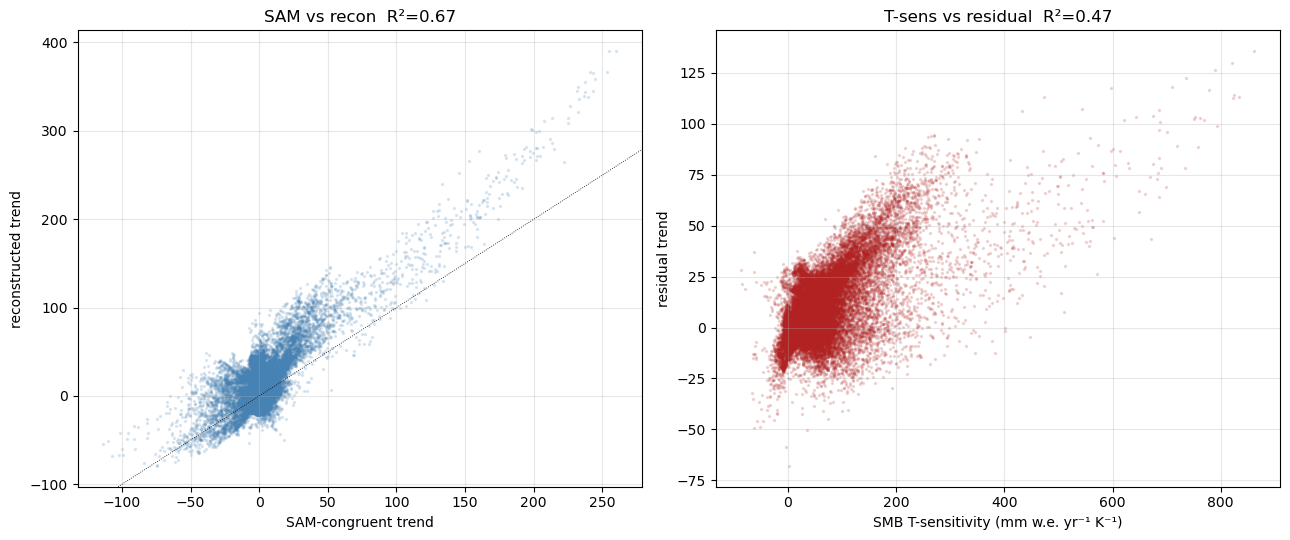

In [ ]:
smb_rd = detrend_cols(_cols(smb_ann, 1979, SAM_HI)); smb_rd25 = detrend_cols(_cols(smb_ann, 1979, 2025))
t2m_rd = detrend_cols(_cols(t2m_ann, 1979, 2025))
SAMsens_rate = (sam_sd[:,None]*smb_rd).sum(0) / (sam_sd @ sam_sd)
Tsens_rate   = (t2m_rd*smb_rd25).sum(0) / (t2m_rd*t2m_rd).sum(0)
recon_tr   = trend_cols(racmo_smb_recon.reshape(200,-1)[sl][:, valid_cells]) * 10
samcong_tr = SAMsens_rate * sam_tr; resid_tr = recon_tr - samcong_tr
f1 = np.isfinite(recon_tr) & np.isfinite(samcong_tr); r1 = np.corrcoef(recon_tr[f1], samcong_tr[f1])[0,1]
f2 = np.isfinite(resid_tr) & np.isfinite(Tsens_rate); r2 = np.corrcoef(resid_tr[f2], Tsens_rate[f2])[0,1]
print(f"SAM-congruent explains {100*r1**2:5.1f}% of spatial variance (r={r1:+.2f})")
print(f"T-sensitivity explains {100*r2**2:5.1f}% of residual variance (r={r2:+.2f})")
fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))
ax[0].scatter(samcong_tr[f1], recon_tr[f1], s=2, alpha=0.15, color="steelblue"); ax[0].axline((0,0), slope=1, color="k", lw=0.6, ls=":")
ax[0].set(xlabel="SAM-congruent trend", ylabel="reconstructed trend", title=f"SAM vs recon  R²={r1**2:.2f}")
ax[1].scatter(Tsens_rate[f2], resid_tr[f2], s=2, alpha=0.15, color="firebrick")
ax[1].set(xlabel="SMB T-sensitivity (mm w.e. yr⁻¹ K⁻¹)", ylabel="residual trend", title=f"T-sens vs residual  R²={r2**2:.2f}")
for a in ax: a.grid(alpha=0.3)
plt.tight_layout(); plt.show()



SAM-congruent explains        66.3% (r=+0.81)
Bromwich prediction explains  45.0% of residual variance (r=+0.67)


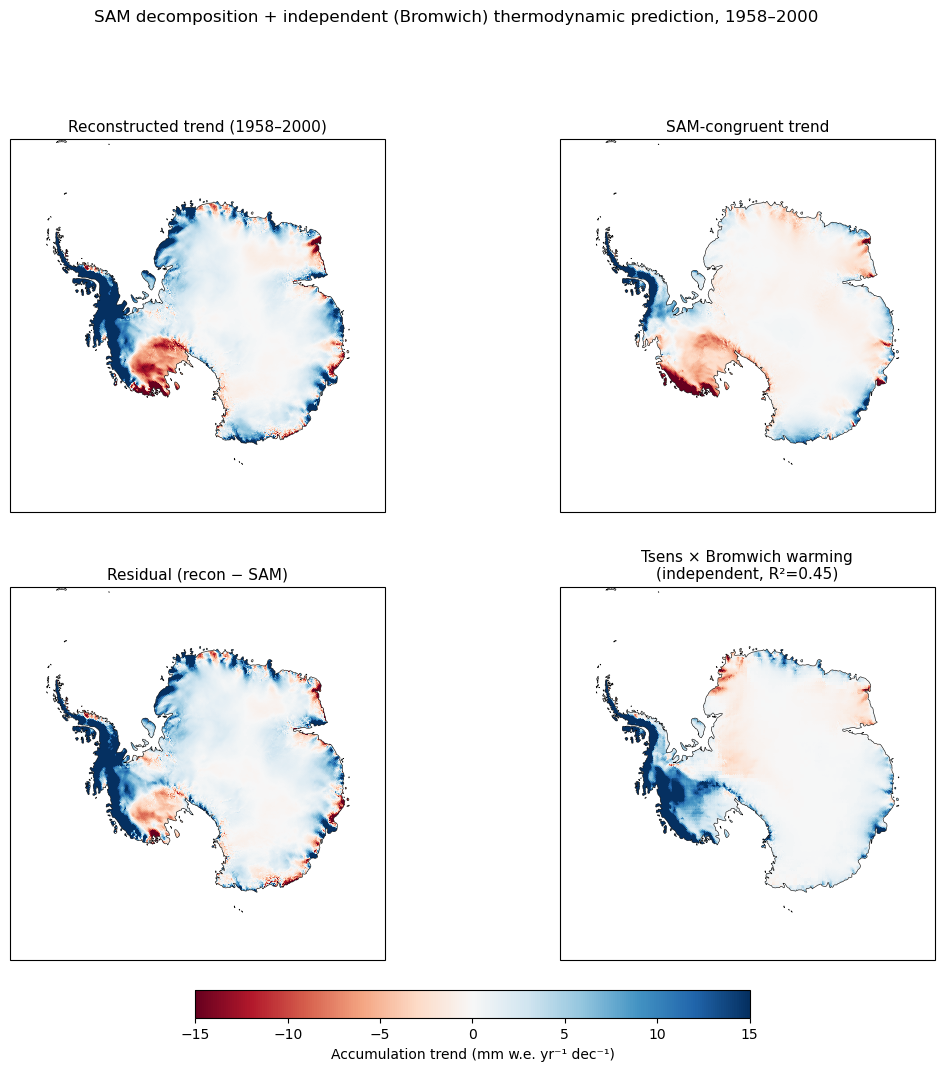

In [ ]:
def paint_cells(v): f = np.full(NY*NX, np.nan); f[valid_cells] = v; return f.reshape(NY, NX)
def rc(a, b): m = np.isfinite(a) & np.isfinite(b); return np.corrcoef(a[m], b[m])[0,1]
sl58 = slice(1958-1801, 2000-1801+1)
recon_tr58 = trend_cols(racmo_smb_recon.reshape(200,-1)[sl58][:, valid_cells]) * 10
sam_tr58   = np.polyfit(np.arange(43), sam.loc[1958:2000].values, 1)[0] * 10
samcong58  = SAMsens_rate * sam_tr58; resid58 = recon_tr58 - samcong58
pred_brom  = Tsens_rate * brom_trend(1958, 2000)[ii]                       # independent thermodynamic prediction
r_res = rc(resid58, pred_brom); r_sam = rc(recon_tr58, samcong58)
print(f"SAM-congruent explains       {100*r_sam**2:5.1f}% (r={r_sam:+.2f})")
print(f"Bromwich prediction explains {100*r_res**2:5.1f}% of residual variance (r={r_res:+.2f})")
vlim = 15
panels = [("Reconstructed trend (1958–2000)", recon_tr58), ("SAM-congruent trend", samcong58),
          ("Residual (recon − SAM)", resid58), (f"Tsens × Bromwich warming\n(independent, R²={r_res**2:.2f})", pred_brom)]
fig, axes = plt.subplots(2, 2, figsize=(13, 13), subplot_kw={"projection": ccrs.SouthPolarStereo()})
for ax, (title, field) in zip(axes.ravel(), panels):
    ax.set_extent([-180,180,-90,-60], ccrs.PlateCarree()); ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
    im = ax.pcolormesh(lon_racmo, lat_racmo, paint_cells(field), transform=ccrs.PlateCarree(), cmap="RdBu", vmin=-vlim, vmax=vlim, zorder=1)
    ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=2); ax.add_feature(cfeature.COASTLINE, lw=0.4, zorder=3)
    ax.set_title(title, fontsize=11)
cb = fig.colorbar(im, ax=axes, orientation="horizontal", pad=0.03, shrink=0.55); cb.set_label("Accumulation trend (mm w.e. yr⁻¹ dec⁻¹)")
fig.suptitle("SAM decomposition + independent (Bromwich) thermodynamic prediction, 1958–2000", fontsize=12); plt.show()


reg    mean inflation   PI (1801-1900)  modern (1979-2000)
AIS              1.21             1.24                1.09
WAIS             1.04             1.04                1.02
EAIS             1.26             1.30                1.15
AP               1.11             1.17                1.03


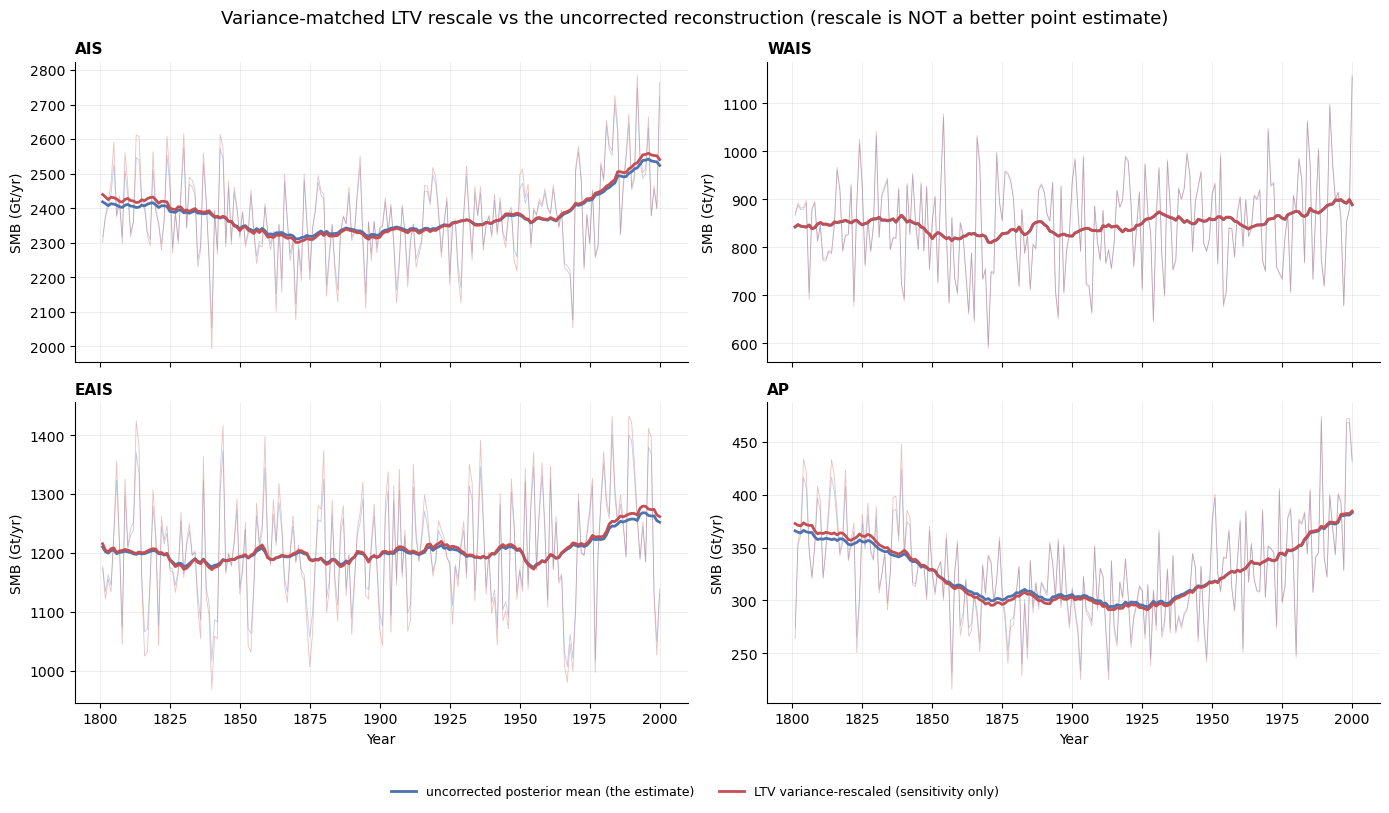

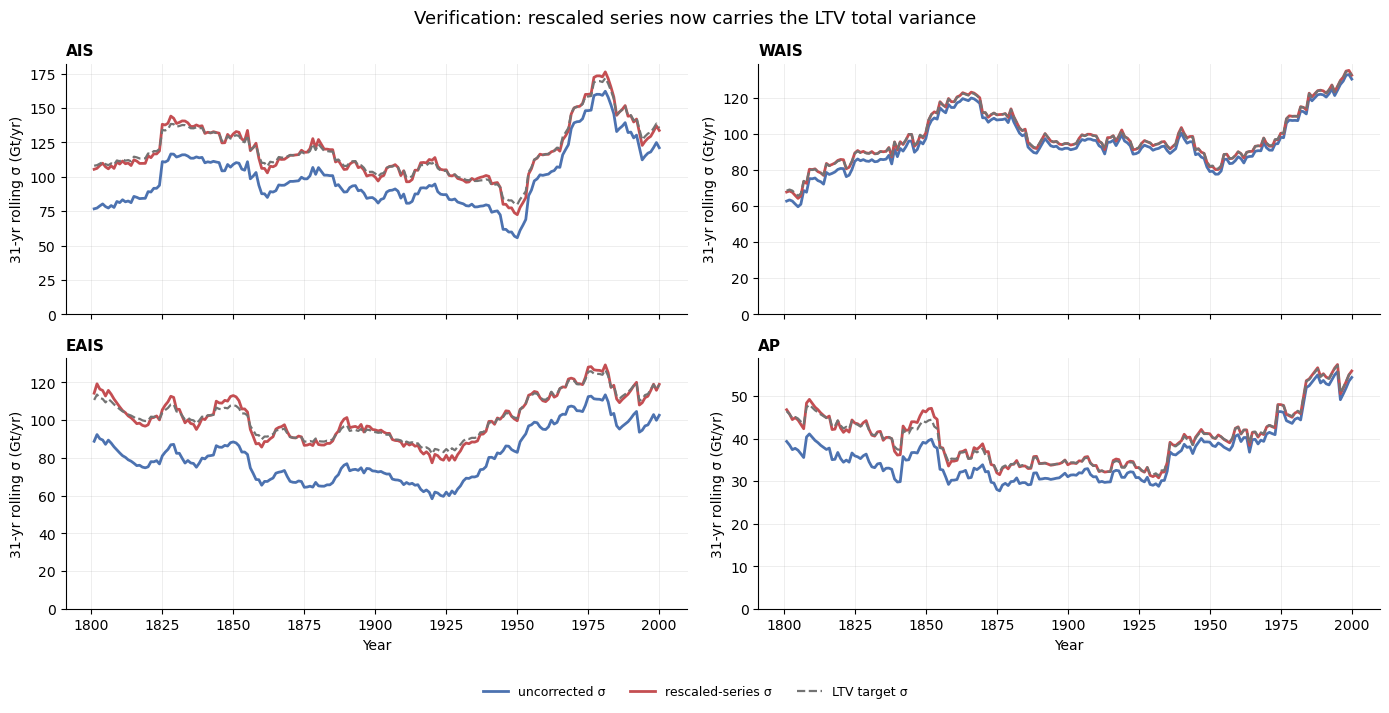

In [33]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ---------------------------------------------------------------------------
# SENSITIVITY CHECK ONLY: variance-matched (LTV-rescaled) series.
# This stretches the posterior mean's anomalies to carry the LTV total variance.
# It is NOT a better point estimate (it degrades MSE) and must NOT be used
# downstream — the reconstruction stays `reg_mean`, the null stays `ggm_fits`.
# ---------------------------------------------------------------------------
W = 31
_r = lambda x: pd.Series(np.asarray(x, float)).rolling(W, center=True, min_periods=max(4, W//2))
roll_mean = lambda x: _r(x).mean().values
roll_var  = lambda x: _r(x).var(ddof=1).values

reg_mean = smb_reg_ens.mean(1); reg_var = smb_reg_ens.var(1, ddof=1)
years_r  = np.arange(1801, 1801 + reg_mean.shape[0])
C_UNC, C_LTV, C_REF = "#4C72B0", "#C44E52", "0.45"

recon_ltv_rescaled = np.empty_like(reg_mean); finf = np.empty_like(reg_mean); ltv_sd = np.empty_like(reg_mean)
for k in range(4):
    v_mean, v_post = roll_var(reg_mean[:, k]), roll_mean(reg_var[:, k])
    f = pd.Series(np.sqrt((v_mean + v_post) / v_mean)).ffill().bfill().values   # inflation factor
    base = reg_mean[0:100, k].mean()                                            # 1801-1900 baseline
    recon_ltv_rescaled[:, k] = base + (reg_mean[:, k] - base) * f
    finf[:, k] = f; ltv_sd[:, k] = np.sqrt(v_mean + v_post)

print(f"{'reg':5s}{'mean inflation':>16s}{'PI (1801-1900)':>17s}{'modern (1979-2000)':>20s}")
for k, r in enumerate(region_names):
    print(f"{r:5s}{np.nanmean(finf[:,k]):16.2f}{np.nanmean(finf[0:100,k]):17.2f}{np.nanmean(finf[178:200,k]):20.2f}")

# --- Figure 1: uncorrected posterior mean vs LTV-rescaled series ---
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
for ax, (k, r) in zip(axes.ravel(), enumerate(region_names)):
    ax.plot(years_r, reg_mean[:, k],            color=C_UNC, lw=0.6, alpha=0.35)
    ax.plot(years_r, recon_ltv_rescaled[:, k],  color=C_LTV, lw=0.6, alpha=0.35)
    ax.plot(years_r, roll_mean(reg_mean[:, k]),           color=C_UNC, lw=2)
    ax.plot(years_r, roll_mean(recon_ltv_rescaled[:, k]), color=C_LTV, lw=2)
    ax.set_title(r, fontsize=11, fontweight="bold", loc="left")
    ax.set_ylabel("SMB (Gt/yr)"); ax.grid(alpha=0.25, lw=0.6)
    for sp in ("top", "right"): ax.spines[sp].set_visible(False)
for ax in axes[-1, :]: ax.set_xlabel("Year")
fig.legend(handles=[Line2D([0],[0], color=C_UNC, lw=2, label="uncorrected posterior mean (the estimate)"),
                    Line2D([0],[0], color=C_LTV, lw=2, label="LTV variance-rescaled (sensitivity only)")],
           loc="lower center", ncol=2, frameon=False, fontsize=9, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Variance-matched LTV rescale vs the uncorrected reconstruction "
             "(rescale is NOT a better point estimate)", fontsize=13)
fig.tight_layout(rect=[0, 0.04, 1, 1]); plt.show()

# --- Figure 2: verification — the rescaled series should carry the LTV variance ---
fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=True)
for ax, (k, r) in zip(axes.ravel(), enumerate(region_names)):
    ax.plot(years_r, np.sqrt(roll_var(reg_mean[:, k])),           color=C_UNC, lw=2)
    ax.plot(years_r, np.sqrt(roll_var(recon_ltv_rescaled[:, k])), color=C_LTV, lw=2)
    ax.plot(years_r, ltv_sd[:, k], color=C_REF, lw=1.6, ls="--")
    ax.set_title(r, fontsize=11, fontweight="bold", loc="left")
    ax.set_ylabel(f"{W}-yr rolling σ (Gt/yr)"); ax.set_ylim(bottom=0); ax.grid(alpha=0.25, lw=0.6)
    for sp in ("top", "right"): ax.spines[sp].set_visible(False)
for ax in axes[-1, :]: ax.set_xlabel("Year")
fig.legend(handles=[Line2D([0],[0], color=C_UNC, lw=2, label="uncorrected σ"),
                    Line2D([0],[0], color=C_LTV, lw=2, label="rescaled-series σ"),
                    Line2D([0],[0], color=C_REF, lw=1.6, ls="--", label="LTV target σ")],
           loc="lower center", ncol=3, frameon=False, fontsize=9, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Verification: rescaled series now carries the LTV total variance", fontsize=13)
fig.tight_layout(rect=[0, 0.04, 1, 1]); plt.show()


reg    ToE uncorrected  ToE rescaled
AIS               2001          2002
WAIS              None          None
EAIS              2011          2010
AP                None          None


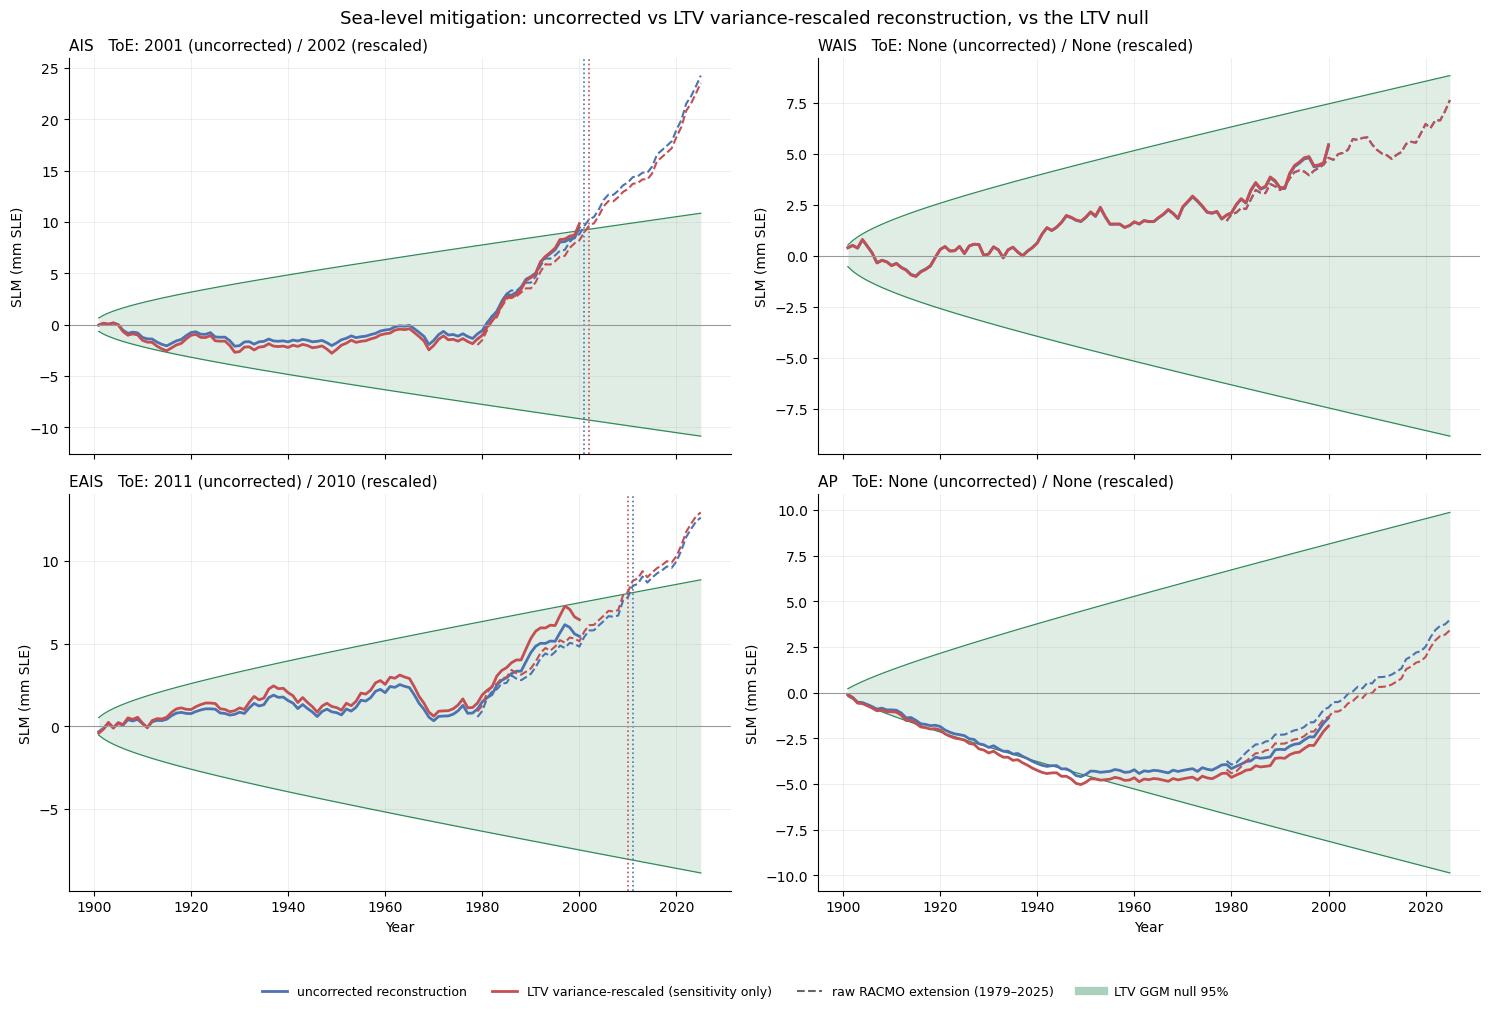

In [34]:
import numpy as np, matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# SENSITIVITY CHECK: SLM computed from the LTV variance-rescaled series vs the uncorrected one.
GT, NB, NA = 361.8, 100, 125
raw = {"AIS": ais_rac, "WAIS": wais_rac, "EAIS": eais_rac, "AP": ap_rac}
C_UNC, C_LTV, C_NULL = "#4C72B0", "#C44E52", "seagreen"

def slm_cum(ts, b=slice(0, 100)):
    ts = np.asarray(ts, float); return np.cumsum(ts - ts[b].mean()) / GT
def extend_slm(recon_ts, obs_ts, b=slice(0, 100)):
    r = np.asarray(recon_ts, float); base = r[b].mean(); cum = np.sum(r[:178] - base) / GT
    return cum + np.cumsum((np.asarray(obs_ts, float) - base) / GT)
def slm_sigma(fit):
    R = _toeplitz(_ggm_acf(fit["kappa"], fit["phi"], NB+NA) * fit["sigma_w"]**2)
    return np.array([np.sqrt((a := np.concatenate([np.full(NB,-n/NB),np.ones(n)])) @ R[:NB+n,:NB+n] @ a)/GT
                     for n in range(1, NA+1)])
def emergence(traj, sig, yy):
    out = traj > 1.96*sig
    for i in range(len(yy)):
        if out[i:].all(): return int(yy[i])
    return None

years, cent, yr_obs = np.arange(1901, 2026), np.arange(1901, 2001), np.arange(1979, 2026)
fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True)
print(f"{'reg':5s}{'ToE uncorrected':>17s}{'ToE rescaled':>14s}")
for ax, (k, r) in zip(axes.ravel(), enumerate(region_names)):
    unc, res = reg_mean[:, k], recon_ltv_rescaled[:, k]
    slm_u, slm_r = slm_cum(unc), slm_cum(res)
    ext_u = extend_slm(unc, raw[r].loc[1979:2025].values)
    ext_r = extend_slm(res, raw[r].loc[1979:2025].values)
    sig = slm_sigma(ggm_fits[r])
    toe_u = emergence(np.concatenate([slm_u[100:178], ext_u]), sig, years)
    toe_r = emergence(np.concatenate([slm_r[100:178], ext_r]), sig, years)

    ax.fill_between(years, -1.96*sig, 1.96*sig, color=C_NULL, alpha=0.15, lw=0)
    ax.plot(years,  1.96*sig, color=C_NULL, lw=0.9); ax.plot(years, -1.96*sig, color=C_NULL, lw=0.9)
    ax.plot(cent, slm_u[100:200], color=C_UNC, lw=2)
    ax.plot(yr_obs, ext_u, color=C_UNC, lw=1.5, ls="--")
    ax.plot(cent, slm_r[100:200], color=C_LTV, lw=2)
    ax.plot(yr_obs, ext_r, color=C_LTV, lw=1.5, ls="--")
    if toe_u: ax.axvline(toe_u, color=C_UNC, lw=1.2, ls=":")
    if toe_r: ax.axvline(toe_r, color=C_LTV, lw=1.2, ls=":")
    ax.axhline(0, color="0.6", lw=0.8)
    ax.set_title(f"{r}   ToE: {toe_u} (uncorrected) / {toe_r} (rescaled)", fontsize=11, loc="left")
    ax.set_ylabel("SLM (mm SLE)"); ax.grid(alpha=0.25, lw=0.6)
    for sp in ("top", "right"): ax.spines[sp].set_visible(False)
    print(f"{r:5s}{str(toe_u):>17s}{str(toe_r):>14s}")
for ax in axes[-1, :]: ax.set_xlabel("Year")

fig.legend(handles=[Line2D([0],[0], color=C_UNC, lw=2, label="uncorrected reconstruction"),
                    Line2D([0],[0], color=C_LTV, lw=2, label="LTV variance-rescaled (sensitivity only)"),
                    Line2D([0],[0], color="0.4", lw=1.5, ls="--", label="raw RACMO extension (1979–2025)"),
                    Line2D([0],[0], color=C_NULL, lw=6, alpha=0.4, label="LTV GGM null 95%")],
           loc="lower center", ncol=4, frameon=False, fontsize=9, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Sea-level mitigation: uncorrected vs LTV variance-rescaled reconstruction, vs the LTV null",
             fontsize=13)
fig.tight_layout(rect=[0, 0.04, 1, 1]); plt.show()
